## Pre testing (movies)

Here before trying a combination of multiple models, we will define a foundation on how we will run our models.

In [1]:
from preprocessing_class import Preprocessing, load_movies
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
import numpy as np
import string
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [2]:
# load dataset
alltxt, alllabs = load_movies("./Dataset/movies1000/")
alltxt, alllabs = np.array(alltxt), np.array(alllabs)

len(alltxt), len(alllabs), np.unique(alllabs)

(2000, 2000, array([0, 1]))

In [17]:
# train test split here for test in final prediction

X_train, X_test, y_train, y_test = train_test_split(
    alltxt, alllabs, 
    test_size=0.20, 
    random_state=42
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.20, 
    random_state=42
)

len(X_train_sub), len(y_train_sub), len(X_val), len(y_val), len(X_train), len(y_train), len(X_test), len(y_test)

(1280, 1280, 320, 320, 1600, 1600, 400, 400)

### 1.Training time based on vocabulary size, for different modèles

In [4]:
prep = Preprocessing(low_case = True,
        rm_punctuation = True,
        rm_number = False,
        word_norm = None, # stem faster
        pos_tagging = False, # to check
        all_capital = True, # keep all capital words as they are
        cap_name = True, # garder les noms en majuscules, for pos tag
        rm_accent = True, 
        lang = "english",
        punct = string.punctuation + '\n\r\t', # punctuation can contain -, that would be kept
        urls = False 
    )


In [5]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier

final_stopwords_list = stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.95, min_df=2, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer

## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "rf":
        return RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    elif name == "linear_svm":
        return LinearSVC(class_weight="balanced", penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "nb":
        return MultinomialNB()
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(class_weight="balanced", solver=solver,max_iter=max_iter) 

In [ ]:
# this time with cv on the train 
import time
import gc
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

train_time = {}
val_f1     = {}
val_acc     = {}
val_rec    = {}
val_prec      = {}

max_features_test = [500, 1000, 5000, 10000]
models_names      = ["logreg", "linear_svm", "nb", "rf"]

for max_feat in max_features_test:
    print(f"\n--- max_features = {max_feat} ---")
    train_time[max_feat] = {}
    val_f1[max_feat]     = {}
    val_acc[max_feat]     = {}
    val_rec[max_feat]    = {}
    val_prec[max_feat]      = {}

    for model_name in models_names:
        needs_dense = model_name == "nb"
        times, f1s, accs, recs, precs = [], [], [], [], []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

            # fit vectorizer on fold train only — no leakage
            vectoriser = build_vectorizer(
                name="count",
                stop_words=final_stopwords_list,
                max_features=max_feat,
                preprocessor=prep
            )
            X_tr = vectoriser.fit_transform(X_train_fold)
            X_v  = vectoriser.transform(X_val_fold)

            if needs_dense:
                X_tr = X_tr.toarray()
                X_v  = X_v.toarray()

            model = build_model(name=model_name, max_iter=2000)

            start_time = time.time()
            model.fit(X_tr, y_train_fold)
            elapsed = time.time() - start_time

            y_pred_val  = model.predict(X_v)
            y_score_val = (
                model.predict_proba(X_v)[:, 1]
                if needs_dense or hasattr(model, "predict_proba")
                else model.decision_function(X_v)
            )

            times.append(elapsed)
            f1s.append(f1_score(y_val_fold, y_pred_val))
            accs.append(accuracy_score(y_val_fold, y_pred_val))
            recs.append(recall_score(y_val_fold, y_pred_val))
            precs.append(precision_score(y_val_fold, y_pred_val))


            del vectoriser, model, X_tr, X_v, y_pred_val, y_score_val
            gc.collect()

        train_time[max_feat][model_name] = times
        val_f1[max_feat][model_name]     = f1s
        val_acc[max_feat][model_name]     = accs
        val_rec[max_feat][model_name]    = recs
        val_prec[max_feat][model_name]      = precs

        print(f"  {model_name}:"
              f"  time={np.mean(times):.3f}±{np.std(times):.3f}s"
              f"  F1={np.mean(f1s):.4f}±{np.std(f1s):.4f}"
              f"  Acc={np.mean(accs):.4f}±{np.std(accs):.4f}"
              f"  Rec={np.mean(recs):.4f}±{np.std(recs):.4f}"
              f"  Prec={np.mean(precs):.4f}±{np.std(precs):.4f}")


--- max_features = 500 ---
  logreg:  time=0.072±0.026s  F1=0.7447±0.0263  Acc=0.7444±0.0285  Rec=0.7460±0.0282  Prec=0.7444±0.0366
  linear_svm:  time=0.129±0.025s  F1=0.7292±0.0270  Acc=0.7269±0.0293  Rec=0.7359±0.0348  Prec=0.7240±0.0379
  nb:  time=0.002±0.000s  F1=0.7663±0.0174  Acc=0.7675±0.0167  Rec=0.7634±0.0222  Prec=0.7696±0.0207
  rf:  time=0.783±0.110s  F1=0.7433±0.0054  Acc=0.7444±0.0103  Rec=0.7409±0.0165  Prec=0.7466±0.0205

--- max_features = 1000 ---
  logreg:  time=0.054±0.028s  F1=0.7941±0.0241  Acc=0.7925±0.0260  Rec=0.8011±0.0349  Prec=0.7890±0.0362
  linear_svm:  time=0.594±0.043s  F1=0.7818±0.0237  Acc=0.7806±0.0242  Rec=0.7873±0.0311  Prec=0.7773±0.0277
  nb:  time=0.004±0.000s  F1=0.7991±0.0116  Acc=0.8013±0.0094  Rec=0.7923±0.0246  Prec=0.8067±0.0128
  rf:  time=0.662±0.037s  F1=0.7984±0.0178  Acc=0.7950±0.0192  Rec=0.8123±0.0164  Prec=0.7852±0.0239

--- max_features = 5000 ---
  logreg:  time=0.085±0.034s  F1=0.8369±0.0095  Acc=0.8375±0.0105  Rec=0.8348±0.02

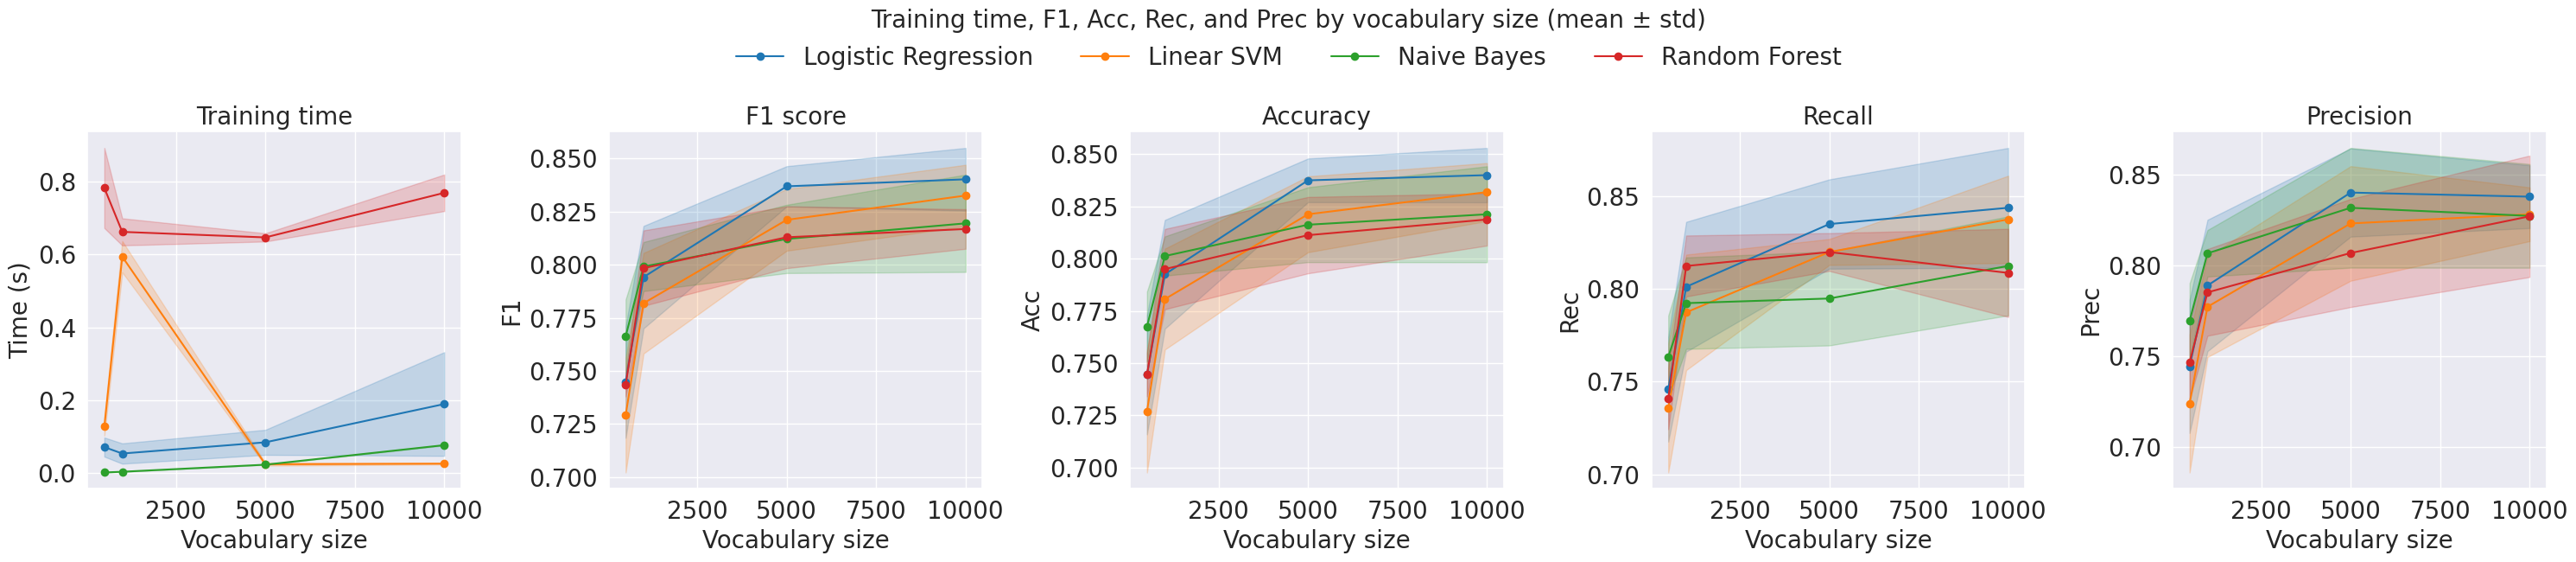

'\nfig, axes = plt.subplots(1, 5, figsize=(30, 6))\n\npalette = sns.color_palette("tab10", n_colors=len(models_names))\n\nfor i, (model_name, color) in enumerate(zip(models_names, palette)):\n    label = label_map.get(model_name, model_name)\n\n    data = [\n        (train_time, val_f1, val_acc, val_rec, val_prec)\n    ]\n\n    for ax, (metric_dict, title, ylabel) in zip(axes, metrics):\n        mean_vals = np.array([np.mean(metric_dict[mf][model_name]) for mf in max_features_test])\n        std_vals  = np.array([np.std(metric_dict[mf][model_name])  for mf in max_features_test])\n\n        ax.plot(max_features_test, mean_vals, marker="o", label=label, color=color)\n        ax.fill_between(\n            max_features_test,\n            mean_vals - std_vals,\n            mean_vals + std_vals,\n            alpha=0.2,\n            color=color,\n        )\n\n\nfor ax, (_, title, ylabel) in zip(axes, metrics):\n    ax.set_title(title)\n    ax.set_xlabel("Vocabulary size")\n    ax.set_ylabel(y

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="darkgrid")

metrics = [
    (train_time, "Training time", "Time (s)"),
    (val_f1,     "F1 score",      "F1"),
    (val_acc,     "Accuracy", "Acc"),
    (val_rec,    "Recall",     "Rec"),
    (val_prec,      "Precision",      "Prec"),
]

label_map = {
    "nb":         "Naive Bayes",
    "logreg":     "Logistic Regression",
    "linear_svm": "Linear SVM",
    "rf":         "Random Forest",
}

palette = sns.color_palette("tab10", n_colors=len(models_names))
fig, axes = plt.subplots(1, 5, figsize=(30,6))

for i, (model_name, color) in enumerate(zip(models_names, palette)):
    label = label_map.get(model_name, model_name)

    data = [
        (train_time, val_f1, val_acc, val_rec, val_prec)
    ]

    for ax, (metric_dict, title, ylabel) in zip(axes, metrics):
        mean_vals = np.array([np.mean(metric_dict[mf][model_name]) for mf in max_features_test])
        std_vals  = np.array([np.std(metric_dict[mf][model_name])  for mf in max_features_test])

        ax.plot(max_features_test, mean_vals, marker="o", label=label, color=color)
        ax.fill_between(
            max_features_test,
            mean_vals - std_vals,
            mean_vals + std_vals,
            alpha=0.2,
            color=color,
        )

for ax, (_, title, ylabel) in zip(axes, metrics):
    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Vocabulary size", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)

# shared legend on top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.05), fontsize=20)

plt.suptitle("Training time, F1, Acc, Rec, and Prec by vocabulary size (mean ± std)", y=1.08, fontsize=20)
plt.tight_layout()
plt.savefig("images/pretest/training_time_f1_acc_rec_prec_by_vocab_size_5.pdf", bbox_inches="tight")
plt.show()


### 2. Cross validation vs split

In [18]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
import numpy as np
import gc

n_runs   = 20
max_feat = 5000

# ── 1. Repeated hold-out ──────────────────────────────────────────────────────
split_f1_scores  = []
split_acc_scores = []
split_rec_scores = []
split_prec_scores = []

for seed in range(n_runs):
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_train, y_train,
        test_size=0.2,
        random_state=seed,
    )
    vectoriser = build_vectorizer(
        name="count",
        stop_words=final_stopwords_list,
        max_features=max_feat,
        preprocessor=prep,
    )
    X_train_vec = vectoriser.fit_transform(X_train_sub)
    X_test_vec  = vectoriser.transform(X_test_sub)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train_sub)

    y_score = model.decision_function(X_test_vec)
    y_pred  = model.predict(X_test_vec)

    split_f1_scores.append(f1_score(y_test_sub, y_pred))
    split_acc_scores.append(accuracy_score(y_test_sub, y_pred))
    split_rec_scores.append(recall_score(y_test_sub, y_pred))
    split_prec_scores.append(precision_score(y_test_sub, y_pred))

    del vectoriser, model, X_train_vec, X_test_vec, y_score, y_pred
    gc.collect()

split_f1_scores  = np.array(split_f1_scores)
split_acc_scores = np.array(split_acc_scores)
split_rec_scores = np.array(split_rec_scores)
split_prec_scores = np.array(split_prec_scores)

print("Repeated hold-out (20 runs)")
print(f"  F1  — mean: {split_f1_scores.mean():.4f}  std: {split_f1_scores.std():.4f}  scores: {np.round(split_f1_scores, 4)}")
print(f"  Acc — mean: {split_acc_scores.mean():.4f}  std: {split_acc_scores.std():.4f}  scores: {np.round(split_acc_scores, 4)}")
print(f"  Rec — mean: {split_rec_scores.mean():.4f}  std: {split_rec_scores.std():.4f}  scores: {np.round(split_rec_scores, 4)}")
print(f"  Prec — mean: {split_prec_scores.mean():.4f}  std: {split_prec_scores.std():.4f}  scores: {np.round(split_prec_scores, 4)}")

# ── 2. Stratified K-Fold CV ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_f1_scores  = []
cv_acc_scores = []
cv_rec_scores = []
cv_prec_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_test_fold  = X_train[test_idx]
    y_test_fold  = y_train[test_idx]

    vectoriser = build_vectorizer(
        name="count",
        stop_words=final_stopwords_list,
        max_features=max_feat,
        preprocessor=prep,
    )
    X_train_vec = vectoriser.fit_transform(X_train_fold)
    X_test_vec  = vectoriser.transform(X_test_fold)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train_fold)

    y_score = model.decision_function(X_test_vec)
    y_pred  = model.predict(X_test_vec)

    cv_f1_scores.append(f1_score(y_test_fold, y_pred))
    cv_acc_scores.append(accuracy_score(y_test_fold, y_pred))
    cv_rec_scores.append(recall_score(y_test_fold, y_pred))
    cv_prec_scores.append(precision_score(y_test_fold, y_pred))


    print(f"  Fold {fold_idx}/5 — : F1: {cv_f1_scores[-1]:.4f}  Acc: {cv_acc_scores[-1]:.4f}  Rec: {cv_rec_scores[-1]:.4f}  Prec: {cv_prec_scores[-1]:.4f}")

    del vectoriser, model, X_train_vec, X_test_vec, y_score, y_pred
    gc.collect()

cv_acc_scores = np.array(cv_acc_scores)
cv_f1_scores  = np.array(cv_f1_scores)
cv_rec_scores = np.array(cv_rec_scores)
cv_prec_scores = np.array(cv_prec_scores)

print("\nStratified 5-fold CV")
print(f"  Acc — mean: {cv_acc_scores.mean():.4f}  std: {cv_acc_scores.std():.4f}  scores: {np.round(cv_acc_scores, 4)}")
print(f"  F1  — mean: {cv_f1_scores.mean():.4f}  std: {cv_f1_scores.std():.4f}  scores: {np.round(cv_f1_scores, 4)}")
print(f"  Rec — mean: {cv_rec_scores.mean():.4f}  std: {cv_rec_scores.std():.4f}  scores: {np.round(cv_rec_scores, 4)}")
print(f"  Prec — mean: {cv_prec_scores.mean():.4f}  std: {cv_prec_scores.std():.4f}  scores: {np.round(cv_prec_scores, 4)}")

Repeated hold-out (20 runs)
  F1  — mean: 0.8284  std: 0.0167  scores: [0.8485 0.7925 0.8158 0.8383 0.8491 0.8282 0.8103 0.8246 0.8318 0.8529
 0.8308 0.8274 0.822  0.8475 0.8141 0.8075 0.8481 0.8094 0.8478 0.8211]
  Acc — mean: 0.8281  std: 0.0148  scores: [0.8438 0.7938 0.825  0.8469 0.85   0.825  0.8156 0.8219 0.8281 0.8438
 0.8281 0.8344 0.8281 0.8312 0.8188 0.8062 0.85   0.8219 0.8406 0.8094]
  Rec — mean: 0.8225  std: 0.0273  scores: [0.8284 0.7826 0.8052 0.8355 0.8491 0.8491 0.84   0.7791 0.8553 0.848
 0.8182 0.7888 0.8301 0.8197 0.8301 0.7602 0.8375 0.8176 0.8659 0.8092]
  Prec — mean: 0.8356  std: 0.0283  scores: [0.8696 0.8025 0.8267 0.8411 0.8491 0.8084 0.7826 0.8758 0.8095 0.858
 0.8438 0.8699 0.8141 0.8772 0.7987 0.8609 0.859  0.8013 0.8304 0.8333]
  Fold 1/5 — : F1: 0.8489  Acc: 0.8531  Rec: 0.8302  Prec: 0.8684
  Fold 2/5 — : F1: 0.8333  Acc: 0.8313  Rec: 0.8438  Prec: 0.8232
  Fold 3/5 — : F1: 0.8141  Acc: 0.8187  Rec: 0.7937  Prec: 0.8355
  Fold 4/5 — : F1: 0.8350  Acc:

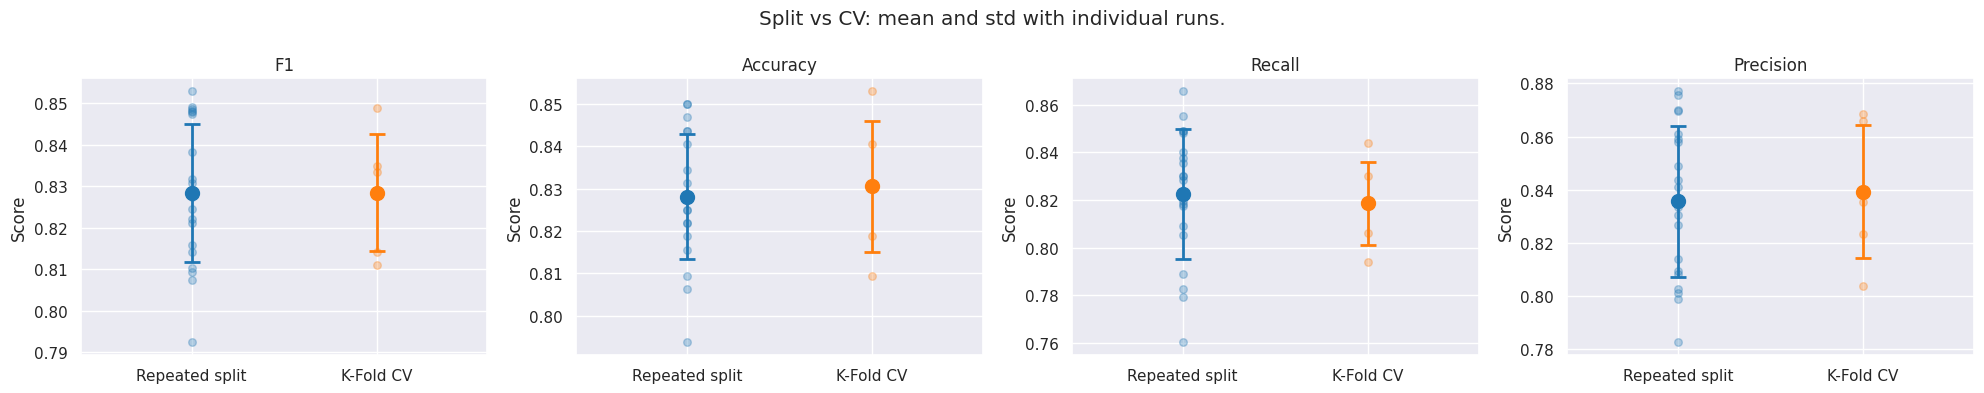

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
palette = sns.color_palette("tab10")

metrics     = ["F1", "Accuracy", "Recall", "Precision"]
split_means = [split_f1_scores.mean(), split_acc_scores.mean(), split_rec_scores.mean(), split_prec_scores.mean()]
split_stds  = [split_f1_scores.std(),  split_acc_scores.std(),  split_rec_scores.std(),  split_prec_scores.std()]
cv_means    = [cv_f1_scores.mean(),    cv_acc_scores.mean(),    cv_rec_scores.mean(),    cv_prec_scores.mean()]
cv_stds     = [cv_f1_scores.std(),     cv_acc_scores.std(),     cv_rec_scores.std(),     cv_prec_scores.std()]

score_map = {
    "F1":                (split_f1_scores,  cv_f1_scores),
    "Accuracy":          (split_acc_scores,  cv_acc_scores),
    "Recall":            (split_rec_scores,  cv_rec_scores),
    "Precision":         (split_prec_scores,  cv_prec_scores),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)

for ax, metric, s_mean, s_std, cv_mean, cv_std in zip(
        axes, metrics, split_means, split_stds, cv_means, cv_stds):

    split_scores, cv_scores = score_map[metric]

    ax.scatter(np.zeros(len(split_scores)), split_scores,
               color=palette[0], alpha=0.3, zorder=1, s=30)
    ax.scatter(np.ones(len(cv_scores)), cv_scores,
               color=palette[1], alpha=0.3, zorder=1, s=30)

    for x_pos, mean, std, color, label in [
        (0, s_mean,  s_std,  palette[0], "Repeated split"),
        (1, cv_mean, cv_std, palette[1], "K-Fold CV"),
    ]:
        ax.errorbar(x_pos, mean, yerr=std,
                    fmt="o", color=color, label=label,
                    markersize=10, capsize=6, capthick=2,
                    linewidth=2, zorder=2)

    ax.set_xlim(-0.6, 1.6)
    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Repeated split", "K-Fold CV"])
    # ax.legend(loc="lower center", bbox_to_anchor=(0.5, 0.01))

plt.suptitle("Split vs CV: mean and std with individual runs.")
plt.tight_layout()
plt.savefig("images/pretest/split_cv_movies.pdf")
plt.show()

### 3. Test of different preprocessing

Here we test different preprocessing to see what is the most efficient. We will use Tfidf vectorizer and logistic regression to evaluate.
- 1. no preprocessing
- 2. lower case and no punctuation
- 3. add remove accents
- 4. add lemmatisation 
- 5. add stemming (no lemma)
- 6. no punctuation only

In [31]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

#lower case and no punctuation
prep2 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

#add remove accents
prep3 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = True, 
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )
# add lemma
prep4 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "lemma", # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False,  # check if changes!!!!
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

# add stemming
prep5 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

# no punctuation only
prep6 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

from nltk.stem import SnowballStemmer 
import spacy, unicodedata

stopwords_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in final_stopwords_list]

stemmer = SnowballStemmer("english")
stemmed_stopwords = [stemmer.stem(word) for word in final_stopwords_list]
stemmed_stopw_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in stemmed_stopwords]

NLP_ENG = spacy.load('en_core_web_sm',disable=["parser", "ner"])

lemma_stopwords = []

for word in final_stopwords_list:
    doc = NLP_ENG(word)
    for token in doc:
        lemma_stopwords.append(token.lemma_.lower())

lemma_stopwords_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in lemma_stopwords]

In [32]:
# plot with prep6
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import gc

preprocessors = {
    "prep1_raw":[None, None,"count"],
    "prep2_lower+punct":[prep2, final_stopwords_list,"count"],
    "prep3_+accent_removal":[prep3, stopwords_no_accent,"count"],
    "prep4_+lemmatisation": [prep4, lemma_stopwords_no_accent,"count"],
    "prep5_+stemming":[prep5, stemmed_stopw_no_accent,  "count"],
    "prep6_+no_punctuation":[prep6, final_stopwords_list,"count"],
    "prep1_raw_tfidf":[None, None,"tfidf"],
    "prep2_lower+punct_tfidf":[prep2, final_stopwords_list,"tfidf"],
    "prep3_+accent_removal_tfidf":[prep3, stopwords_no_accent,"tfidf"],
    "prep4_+lemmatisation_tfidf": [prep4, lemma_stopwords_no_accent,"tfidf"],
    "prep5_+stemming_tfidf":[prep5, stemmed_stopw_no_accent,"tfidf"],
    "prep6_+no_punctuation_tfidf":[prep6, final_stopwords_list,"tfidf"]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, el in preprocessors.items():
    preproc, stop_w, vect_type = el

    fold_metrics = {"acc": [], "rec": [], "prec": [], "f1": []}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        vectoriser = build_vectorizer(
            name=vect_type,
            stop_words=stop_w,
            max_features=5000,
            **({"preprocessor": preproc} if preproc is not None else {})
        )

        X_train_vec = vectoriser.fit_transform(X_train_fold)
        X_val_vec   = vectoriser.transform(X_val_fold)

        model = LogisticRegression(solver="lbfgs", max_iter=2000)
        model.fit(X_train_vec, y_train_fold)

        y_val_score = model.decision_function(X_val_vec)
        y_val_pred  = model.predict(X_val_vec)

        fold_metrics["acc"].append(accuracy_score(y_val_fold, y_val_pred))
        fold_metrics["rec"].append(recall_score(y_val_fold, y_val_pred))
        fold_metrics["prec"].append(precision_score(y_val_fold, y_val_pred))
        fold_metrics["f1"].append(f1_score(y_val_fold, y_val_pred))

        del vectoriser, model, X_train_vec, X_val_vec, y_val_score, y_val_pred
        gc.collect()

    results.append({
        "preprocessor": name,
        "vect_type":    vect_type,
        "mean_acc":      np.mean(fold_metrics["acc"]),
        "std_acc":       np.std(fold_metrics["acc"]),
        "mean_rec":     np.mean(fold_metrics["rec"]),
        "std_rec":      np.std(fold_metrics["rec"]),
        "mean_prec":      np.mean(fold_metrics["prec"]),
        "std_prec":       np.std(fold_metrics["prec"]),
        "mean_f1":      np.mean(fold_metrics["f1"]),
        "std_f1":       np.std(fold_metrics["f1"]),
    })

    print(f"{name}")
    print(f"  ACC : {np.mean(fold_metrics['acc']):.4f} ± {np.std(fold_metrics['acc']):.4f}")
    print(f"  REC : {np.mean(fold_metrics['rec']):.4f} ± {np.std(fold_metrics['rec']):.4f}")
    print(f"  PREC: {np.mean(fold_metrics['prec']):.4f} ± {np.std(fold_metrics['prec']):.4f}")
    print(f"  F1  : {np.mean(fold_metrics['f1']):.4f} ± {np.std(fold_metrics['f1']):.4f}")
    print()

# --- Split into two DataFrames ---
df_all   = pd.DataFrame(results)
df_count = df_all[df_all["vect_type"] == "count"].drop(columns="vect_type").reset_index(drop=True)
df_tfidf = df_all[df_all["vect_type"] == "tfidf"].drop(columns="vect_type").reset_index(drop=True)

print("=== COUNT ===")
print(df_count.to_string(index=False))
print("\n=== TFIDF ===")
print(df_tfidf.to_string(index=False))

prep1_raw
  ACC : 0.8206 ± 0.0121
  REC : 0.8186 ± 0.0365
  PREC: 0.8234 ± 0.0272
  F1  : 0.8199 ± 0.0131

prep2_lower+punct
  ACC : 0.8394 ± 0.0102
  REC : 0.8348 ± 0.0240
  PREC: 0.8434 ± 0.0247
  F1  : 0.8385 ± 0.0093

prep3_+accent_removal
  ACC : 0.8394 ± 0.0102
  REC : 0.8348 ± 0.0240
  PREC: 0.8434 ± 0.0247
  F1  : 0.8385 ± 0.0093

prep4_+lemmatisation
  ACC : 0.8356 ± 0.0131
  REC : 0.8348 ± 0.0176
  PREC: 0.8371 ± 0.0284
  F1  : 0.8355 ± 0.0106



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-pac

prep5_+stemming
  ACC : 0.8344 ± 0.0052
  REC : 0.8348 ± 0.0152
  PREC: 0.8341 ± 0.0131
  F1  : 0.8342 ± 0.0053



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inco

prep6_+no_punctuation
  ACC : 0.8337 ± 0.0167
  REC : 0.8336 ± 0.0217
  PREC: 0.8338 ± 0.0186
  F1  : 0.8335 ± 0.0167

prep1_raw_tfidf
  ACC : 0.8337 ± 0.0147
  REC : 0.8373 ± 0.0170
  PREC: 0.8328 ± 0.0330
  F1  : 0.8344 ± 0.0109

prep2_lower+punct_tfidf
  ACC : 0.8350 ± 0.0087
  REC : 0.8461 ± 0.0122
  PREC: 0.8282 ± 0.0205
  F1  : 0.8367 ± 0.0056

prep3_+accent_removal_tfidf
  ACC : 0.8350 ± 0.0087
  REC : 0.8461 ± 0.0122
  PREC: 0.8282 ± 0.0205
  F1  : 0.8367 ± 0.0056

prep4_+lemmatisation_tfidf
  ACC : 0.8281 ± 0.0171
  REC : 0.8310 ± 0.0125
  PREC: 0.8278 ± 0.0364
  F1  : 0.8287 ± 0.0135



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-pac

prep5_+stemming_tfidf
  ACC : 0.8331 ± 0.0083
  REC : 0.8398 ± 0.0244
  PREC: 0.8292 ± 0.0189
  F1  : 0.8340 ± 0.0083



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inco

prep6_+no_punctuation_tfidf
  ACC : 0.8425 ± 0.0121
  REC : 0.8511 ± 0.0285
  PREC: 0.8374 ± 0.0222
  F1  : 0.8436 ± 0.0121

=== COUNT ===
         preprocessor  mean_acc  std_acc  mean_rec  std_rec  mean_prec  std_prec  mean_f1   std_f1
            prep1_raw  0.820625 0.012119  0.818561 0.036498   0.823427  0.027179 0.819883 0.013053
    prep2_lower+punct  0.839375 0.010193  0.834827 0.024044   0.843359  0.024679 0.838473 0.009293
prep3_+accent_removal  0.839375 0.010193  0.834827 0.024044   0.843359  0.024679 0.838473 0.009293
 prep4_+lemmatisation  0.835625 0.013050  0.834835 0.017631   0.837124  0.028421 0.835459 0.010622
      prep5_+stemming  0.834375 0.005229  0.834788 0.015162   0.834119  0.013092 0.834250 0.005312
prep6_+no_punctuation  0.833750 0.016700  0.833569 0.021682   0.833801  0.018571 0.833535 0.016712

=== TFIDF ===
               preprocessor  mean_acc  std_acc  mean_rec  std_rec  mean_prec  std_prec  mean_f1   std_f1
            prep1_raw_tfidf  0.833750 0.014711  

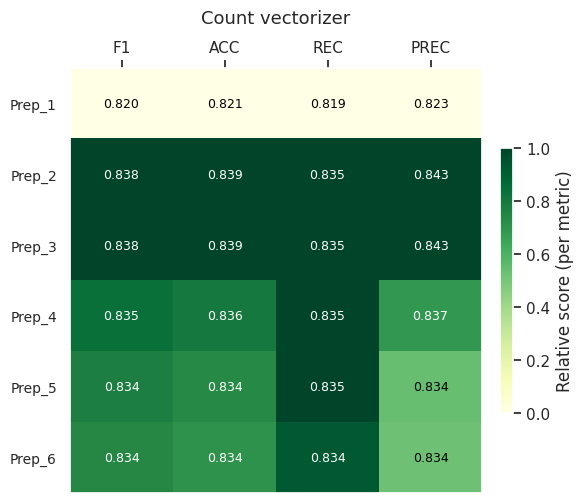

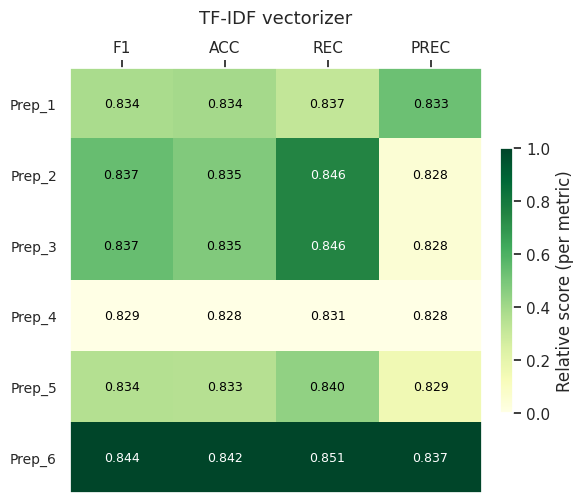

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_heatmap(df, title, filename=None):
    metrics = ["mean_f1", "mean_acc", "mean_rec","mean_prec"]
    metric_labels = ["F1", "ACC", "REC", "PREC"]
    prep_names = df["preprocessor"].tolist()
    
    # --- RAW values (for annotations) ---
    raw_data = df[metrics].values.astype(float)

    # --- NORMALIZED values (for colors only, per column) ---
    col_min = raw_data.min(axis=0)
    col_max = raw_data.max(axis=0)
    norm_data = (raw_data - col_min) / (col_max - col_min + 1e-8)

    fig, ax = plt.subplots(figsize=(6, len(prep_names) * 0.7 + 1))

    # Use normalized data for heatmap colors
    im = ax.imshow(norm_data, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

    # Axes labels
    ax.grid(False)
    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_yticks(range(len(prep_names)))
    ax.set_yticklabels([f"Prep_{i+1}" for i in range(len(prep_names))], fontsize=10)

    # Annotate each cell with TRUE values
    std_cols = ["std_f1", "std_acc", "std_rec", "std_prec"]
    for i in range(len(prep_names)):
        for j, (metric, std_col) in enumerate(zip(metrics, std_cols)):
            mean_val = raw_data[i, j]  
            std_val  = df.iloc[i][std_col]

            text = f"{mean_val:.3f}"

            # Use normalized value for background color
            norm_val = norm_data[i, j]
            bg_color = im.cmap(im.norm(norm_val))
            brightness = 0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2]
            txt_color = "black" if brightness > 0.5 else "white"

            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=txt_color)

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04,
                 label="Relative score (per metric)")
    
    ax.set_title(title, fontsize=13, pad=12)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

plot_heatmap(df_count, "Count vectorizer", "images/pretest/movies_count_heatmap_prep.pdf")
plot_heatmap(df_tfidf, "TF-IDF vectorizer", "images/pretest/movies_tfidf_heatmap_prep.pdf")

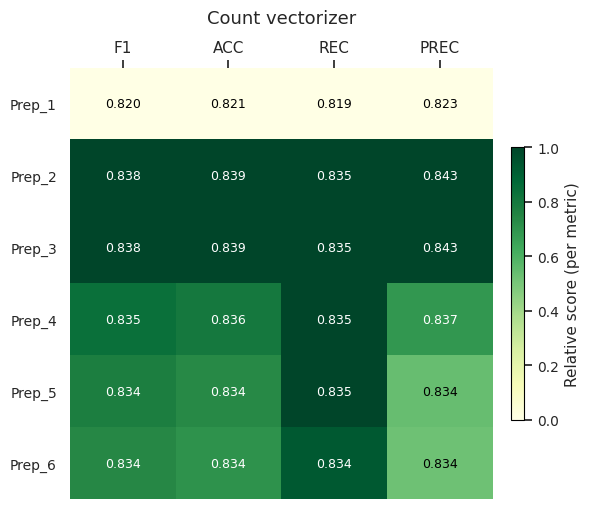

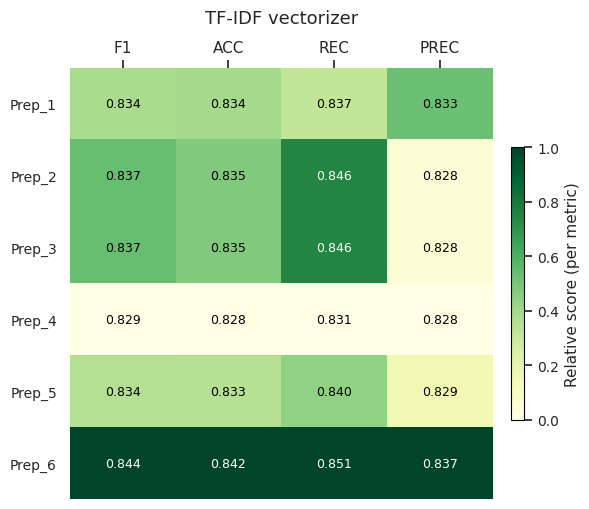

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="darkgrid")  # or "whitegrid" if you prefer
plt.rcParams.update({
    # fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "regular",
    "axes.labelweight": "regular",
    "axes.titlepad": 12,
    # tick labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 10,
    # tick / spine / grid
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "axes.grid.axis": "both",
    "grid.alpha": 0.8,
    # line / patch
    "lines.linewidth": 1.0,
    "patch.linewidth": 0.5,
    "axes.linewidth": 0.8,  # thin black borders
    "axes.edgecolor": "black",
})


#sns.set_theme(style="darkgrid")
#palette = sns.color_palette("tab10")

def plot_heatmap(df, title, filename=None):
    metrics = ["mean_f1", "mean_acc", "mean_rec","mean_prec"]
    metric_labels = ["F1", "ACC", "REC", "PREC"]
    prep_names = df["preprocessor"].tolist()
    
    # --- RAW values (for annotations) ---
    raw_data = df[metrics].values.astype(float)

    # --- NORMALIZED values (for colors only, per column) ---
    col_min = raw_data.min(axis=0)
    col_max = raw_data.max(axis=0)
    norm_data = (raw_data - col_min) / (col_max - col_min + 1e-8)

    fig, ax = plt.subplots(figsize=(6, len(prep_names) * 0.7 + 1))

    # Use normalized data for heatmap colors
    im = ax.imshow(norm_data, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

    # Axes labels
    ax.grid(False)
    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_yticks(range(len(prep_names)))
    ax.set_yticklabels([f"Prep_{i+1}" for i in range(len(prep_names))], fontsize=10)

    # Annotate each cell with TRUE values
    std_cols = ["std_f1", "std_acc", "std_rec", "std_prec"]
    for i in range(len(prep_names)):
        for j, (metric, std_col) in enumerate(zip(metrics, std_cols)):
            mean_val = raw_data[i, j]  
            std_val  = df.iloc[i][std_col]

            text = f"{mean_val:.3f}"

            # Use normalized value for background color
            norm_val = norm_data[i, j]
            bg_color = im.cmap(im.norm(norm_val))
            brightness = 0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2]
            txt_color = "black" if brightness > 0.5 else "white"

            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=txt_color)

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04,
                 label="Relative score (per metric)")
    
    ax.set_title(title, fontsize=13, pad=12)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

plot_heatmap(df_count, "Count vectorizer", "images/pretest/movies_count_heatmap_prep.pdf")
plot_heatmap(df_tfidf, "TF-IDF vectorizer", "images/pretest/movies_tfidf_heatmap_prep.pdf")

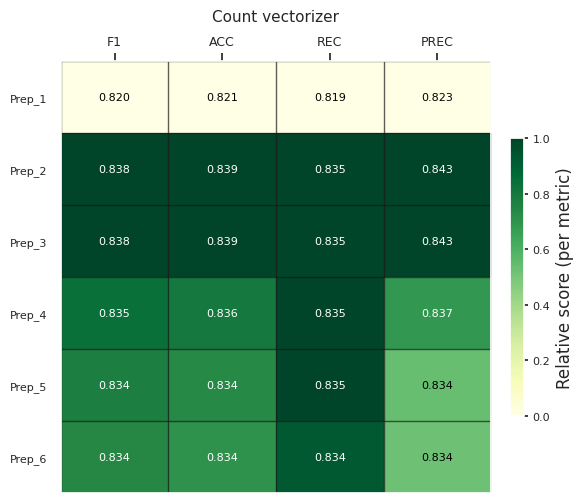

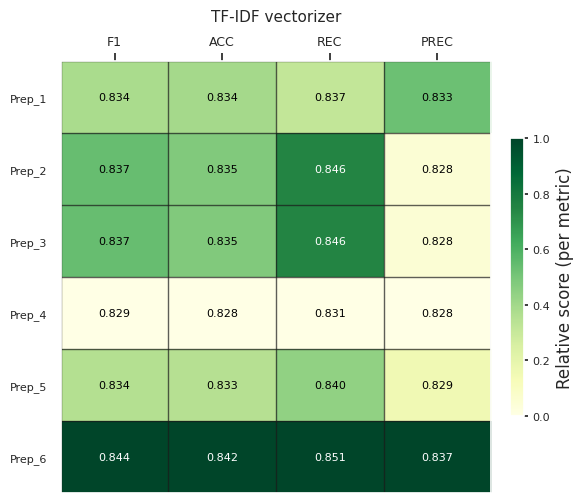

In [44]:
sns.set_theme(style="darkgrid")
palette = sns.color_palette("tab10")


def plot_heatmap(df, title, filename=None):
    metrics = ["mean_f1", "mean_acc", "mean_rec", "mean_prec"]
    metric_labels = ["F1", "ACC", "REC", "PREC"]
    prep_names = df["preprocessor"].tolist()

    # --- RAW values (for annotations) ---
    raw_data = df[metrics].values.astype(float)

    # --- NORMALIZED values (for colors only, per column) ---
    col_min = raw_data.min(axis=0)
    col_max = raw_data.max(axis=0)
    norm_data = (raw_data - col_min) / (col_max - col_min + 1e-8)

    fig, ax = plt.subplots(figsize=(6, len(prep_names) * 0.7 + 1))

    # Use normalized data for heatmap colors
    im = ax.imshow(norm_data, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

    # Axes labels
    ax.grid(False)
    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=9)  # smaller
    ax.set_yticks(range(len(prep_names)))
    ax.set_yticklabels([f"Prep_{i+1}" for i in range(len(prep_names))], fontsize=8)  # smaller

    # --- BOLDER inner cell borders via grid ---
    ax.set_xticks(np.arange(-0.5, len(metric_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(prep_names), 1), minor=True)
    ax.grid(which="minor", color="k", linewidth=1.0, alpha=0.7)  # bolder grid lines
    ax.tick_params(which="minor", length=0)  # hide minor tick marks, keep lines

    # Annotate each cell with TRUE values
    std_cols = ["std_f1", "std_acc", "std_rec", "std_prec"]
    for i in range(len(prep_names)):
        for j, (metric, std_col) in enumerate(zip(metrics, std_cols)):
            mean_val = raw_data[i, j]
            std_val  = df.iloc[i][std_col]

            text = f"{mean_val:.3f}"

            # Use normalized value for background color
            norm_val = norm_data[i, j]
            bg_color = im.cmap(im.norm(norm_val))
            brightness = 0.299 * bg_color[0] + 0.587 * bg_color[1] + 0.114 * bg_color[2]
            txt_color = "black" if brightness > 0.5 else "white"

            ax.text(j, i, text, ha="center", va="center", fontsize=8, color=txt_color)

    # Colorbar: bolder, vertical ticks, smaller label
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Relative score (per metric)")
    cbar.ax.tick_params(labelsize=8)  # smaller ticks
    cbar.ax.tick_params(axis="y", which="both", direction="out", length=3)  # add ticks on right

    # --- Bolder legend / patch border (if you have any legend elsewhere) ---
    # For future consistency, you can set:
    # plt.rcParams["patch.linewidth"] = 1.0  # or 1.5

    ax.set_title(title, fontsize=11, pad=10)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

plot_heatmap(df_count, "Count vectorizer", "images/pretest/movies_count_heatmap_prep.pdf")
plot_heatmap(df_tfidf, "TF-IDF vectorizer", "images/pretest/movies_tfidf_heatmap_prep.pdf")

### 4. Test with n-grams with little preprocessing and preprocessing

In [44]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [45]:
# with cross validation

ranges_ngram = [(1,1), (1,2), (2,2), (1,3), (2,3), (3,3)]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for t in ranges_ngram:
    f1s, aps, aucs = [], [], []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        vectoriser = build_vectorizer(
            name="count",
            stop_words=final_stopwords_list,
            max_features=10000,
            ngram_range=t,
            preprocessor=prep
        )

        X_tr_vec  = vectoriser.fit_transform(X_tr)
        X_val_vec = vectoriser.transform(X_val)

        model = LogisticRegression(solver="lbfgs", max_iter=2000)
        model.fit(X_tr_vec, y_tr)

        y_val_score = model.decision_function(X_val_vec)
        y_val_pred  = model.predict(X_val_vec)

        f1s.append(f1_score(y_val, y_val_pred, average='macro'))
        aps.append(average_precision_score(y_val, y_val_score))
        aucs.append(roc_auc_score(y_val, y_val_score))

        del vectoriser, model, X_tr_vec, X_val_vec
        gc.collect()

    results.append({
        "ngram_range": t,
        "mean_f1":  np.mean(f1s),  "std_f1":  np.std(f1s),
        "mean_ap":  np.mean(aps),  "std_ap":  np.std(aps),
        "mean_auc": np.mean(aucs), "std_auc": np.std(aucs),
    })

    print(f"n-gram range: {t}")
    print(f"  F1 : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"  AP : {np.mean(aps):.4f} ± {np.std(aps):.4f}")
    print(f"  AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

df_ngram = pd.DataFrame(results)
print(df_ngram.to_string(index=False))

n-gram range: (1, 1)
  F1 : 0.7099 ± 0.0045
  AP : 0.9701 ± 0.0015
  AUC: 0.8523 ± 0.0057
n-gram range: (1, 2)
  F1 : 0.7198 ± 0.0058
  AP : 0.9718 ± 0.0012
  AUC: 0.8601 ± 0.0047
n-gram range: (2, 2)
  F1 : 0.5963 ± 0.0062
  AP : 0.9498 ± 0.0014
  AUC: 0.7701 ± 0.0035
n-gram range: (1, 3)
  F1 : 0.7192 ± 0.0072
  AP : 0.9718 ± 0.0013
  AUC: 0.8598 ± 0.0050
n-gram range: (2, 3)
  F1 : 0.5981 ± 0.0070
  AP : 0.9492 ± 0.0012
  AUC: 0.7680 ± 0.0036
n-gram range: (3, 3)
  F1 : 0.4811 ± 0.0031
  AP : 0.8967 ± 0.0013
  AUC: 0.5986 ± 0.0052
ngram_range  mean_f1   std_f1  mean_ap   std_ap  mean_auc  std_auc
     (1, 1) 0.709899 0.004526 0.970130 0.001478  0.852349 0.005661
     (1, 2) 0.719822 0.005778 0.971832 0.001218  0.860061 0.004650
     (2, 2) 0.596340 0.006187 0.949786 0.001418  0.770140 0.003493
     (1, 3) 0.719157 0.007205 0.971760 0.001338  0.859798 0.004986
     (2, 3) 0.598080 0.006998 0.949186 0.001210  0.767951 0.003626
     (3, 3) 0.481061 0.003056 0.896651 0.001341  0.598602 

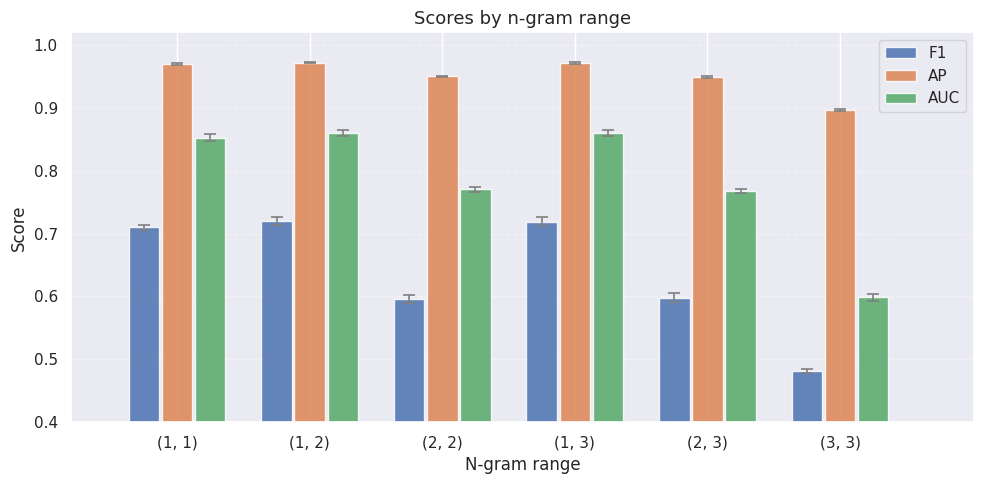

In [68]:
means = {
    'F1':  df_ngram['mean_f1'].tolist(),
    'AP':  df_ngram['mean_ap'].tolist(),
    'AUC': df_ngram['mean_auc'].tolist(),
}
stds = {
    'F1':  df_ngram['std_f1'].tolist(),
    'AP':  df_ngram['std_ap'].tolist(),
    'AUC': df_ngram['std_auc'].tolist(),
}
labels = df_ngram['ngram_range'].astype(str).tolist()

colors = {'F1': sns.color_palette()[0], 'AP': sns.color_palette()[1], 'AUC': sns.color_palette()[2]}

x = np.arange(len(labels))
n_metrics = len(means)
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(10, 5))

for (metric, color), offset in zip([(m, colors[m]) for m in means], offsets):
    bars = ax.bar(x + offset, means[metric], width=width - 0.02,
                  yerr=stds[metric], capsize=4,
                  label=metric, color=color, alpha=0.85,
                  error_kw=dict(elinewidth=1.2, ecolor='gray', capthick=1.2))

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('N-gram range', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Scores by n-gram range', fontsize=13, fontweight='medium')
ax.set_ylim(0.4, 1.02)
ax.set_xlim(-0.8, len(labels) + 0.010)
ax.legend(loc="upper right")
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('images/pretest/pres_ngram_metrics.pdf')
plt.show()

### 5. Vector size 
- word2vec,fastext, doc2vec on trained data, different size

In [8]:
def stopwords_rmv(text, stopwords=final_stopwords_list):
    return " ".join([word for word in text.split() if word not in stopwords])


In [ ]:
# import the 3 models, run them
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# ── helpers ──────────────────────────────────────────────────────────────────

def mean_embed_wv(texts, model):
    """Word2Vec / FastText: mean pool over known words."""
    vecs = []
    for text in texts:
        words = text.split()
        ws = [model.wv[w] for w in words if w in model.wv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(model.vector_size))
    return np.array(vecs)

def embed_doc2vec(texts, model):
    """Doc2Vec: infer one vector per document."""
    return np.array([model.infer_vector(t.split()) for t in texts])

def run_cv(X, y, n_splits=5):
    """Scale + LR inside a pipeline, return mean CV metrics."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
    ])
    scores = cross_validate(pipe, X, y, cv=n_splits,
                            scoring=["f1_macro", "roc_auc",
                                     "average_precision",
                                     "precision_macro", "recall_macro"])
    return {
        "F1":            scores["test_f1_macro"].mean(),
        "F1_std":        scores["test_f1_macro"].std(),
        "AUC":           scores["test_roc_auc"].mean(),
        "AUC_std":       scores["test_roc_auc"].std(),
        "AvgPrec":       scores["test_average_precision"].mean(),
        "AvgPrec_std":   scores["test_average_precision"].std(),
        "Precision":     scores["test_precision_macro"].mean(),
        "Precision_std": scores["test_precision_macro"].std(),
        "Recall":        scores["test_recall_macro"].mean(),
        "Recall_std":    scores["test_recall_macro"].std(),
    }

# ── preprocessing (reuse your existing prep + stopword removal) ───────────────

all_texts = [stopwords_rmv(prep.process(t)) for t in X_train]   # full dataset
all_texts_tok = [t.split() for t in all_texts]                   # tokenized

# ── experiment loop ───────────────────────────────────────────────────────────

SIZES   = [100, 200, 300]
RESULTS = []

for size in SIZES:
    print(f"\n{'='*40}\nVector size: {size}\n{'='*40}")

    # ── Word2Vec (skip-gram) ──────────────────────────────────────────────────
    w2v = Word2Vec(sentences=all_texts_tok, vector_size=size, window=5,
                   min_count=5, sg=1, epochs=5, workers=3)
    X_w2v = mean_embed_wv(all_texts, w2v)
    m = run_cv(X_w2v, y_train)
    RESULTS.append({"model": "Word2Vec", "size": size, **m})
    print(f"Word2Vec  {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

    # ── FastText (skip-gram) ──────────────────────────────────────────────────
    ft = FastText(sentences=all_texts_tok, vector_size=size, window=5,
                  min_count=1, sg=1, epochs=5, workers=3)
    X_ft = mean_embed_wv(all_texts, ft)
    m = run_cv(X_ft, y_train)
    RESULTS.append({"model": "FastText", "size": size, **m})
    print(f"FastText  {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

    # ── Doc2Vec (PV-DBOW, skip-gram equivalent) ───────────────────────────────
    tagged = [TaggedDocument(t.split(), [i]) for i, t in enumerate(all_texts)]
    d2v = Doc2Vec(tagged, vector_size=size, window=5,
                  min_count=1, dm=0, epochs=20, workers=4)
    X_d2v = embed_doc2vec(all_texts, d2v)
    m = run_cv(X_d2v, y_train)
    RESULTS.append({"model": "Doc2Vec", "size": size, **m})
    print(f"Doc2Vec   {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

# ── collect ───────────────────────────────────────────────────────────────────

df_results = pd.DataFrame(RESULTS)
print("\n", df_results.to_string(index=False))



Vector size: 100
Word2Vec  100d → F1=0.5362  AUC=0.7784
FastText  100d → F1=0.5386  AUC=0.7798
Doc2Vec   100d → F1=0.5915  AUC=0.7726

Vector size: 200
Word2Vec  200d → F1=0.5545  AUC=0.7942
FastText  200d → F1=0.5526  AUC=0.7938
Doc2Vec   200d → F1=0.6146  AUC=0.7853

Vector size: 300
Word2Vec  300d → F1=0.5590  AUC=0.7995
FastText  300d → F1=0.5523  AUC=0.7943
Doc2Vec   300d → F1=0.6296  AUC=0.7933

    model  size       F1      AUC  AvgPrec  Precision   Recall
Word2Vec   100 0.536240 0.778371 0.953166   0.675177 0.535386
FastText   100 0.538556 0.779754 0.953939   0.682777 0.536859
 Doc2Vec   100 0.591543 0.772595 0.950942   0.770395 0.570870
Word2Vec   200 0.554514 0.794205 0.957260   0.685309 0.546653
FastText   200 0.552561 0.793843 0.956835   0.690404 0.545477
 Doc2Vec   200 0.614636 0.785280 0.953573   0.773812 0.587358
Word2Vec   300 0.559002 0.799462 0.958088   0.684944 0.549566
FastText   300 0.552267 0.794349 0.956982   0.688675 0.545267
 Doc2Vec   300 0.629583 0.793250 0.

In [78]:
# import the 3 models, run them
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# ── helpers ──────────────────────────────────────────────────────────────────

def mean_embed_wv(texts, model):
    """Word2Vec / FastText: mean pool over known words."""
    vecs = []
    for text in texts:
        words = text.split()
        ws = [model.wv[w] for w in words if w in model.wv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(model.vector_size))
    return np.array(vecs)

def embed_doc2vec(texts, model):
    """Doc2Vec: infer one vector per document."""
    return np.array([model.infer_vector(t.split()) for t in texts])

def run_cv(X, y, n_splits=5):
    """Scale + LR inside a pipeline, return mean CV metrics."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
    ])
    scores = cross_validate(pipe, X, y, cv=n_splits,
                            scoring=["f1_macro", "roc_auc",
                                     "average_precision"])
    return {
        "F1":            scores["test_f1_macro"].mean(),
        "F1_std":        scores["test_f1_macro"].std(),
        "AUC":           scores["test_roc_auc"].mean(),
        "AUC_std":       scores["test_roc_auc"].std(),
        "AvgPrec":       scores["test_average_precision"].mean(),
        "AvgPrec_std":   scores["test_average_precision"].std(),
    }

# ── preprocessing (reuse your existing prep + stopword removal) ───────────────

all_texts = [stopwords_rmv(prep.process(t)) for t in X_train]   # full dataset
all_texts_tok = [t.split() for t in all_texts]                   # tokenized

# ── experiment loop ───────────────────────────────────────────────────────────

SIZES   = [100, 200, 300]
RESULTS = []

for size in SIZES:
    print(f"\n{'='*40}\nVector size: {size}\n{'='*40}")

    # ── Word2Vec (skip-gram) ──────────────────────────────────────────────────
    w2v = Word2Vec(sentences=all_texts_tok, vector_size=size, window=5,
                   min_count=5, sg=1, epochs=5, workers=3)
    X_w2v = mean_embed_wv(all_texts, w2v)
    m = run_cv(X_w2v, y_train)
    RESULTS.append({"model": "Word2Vec", "size": size, **m})
    print(f"Word2Vec  {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

    # ── FastText (skip-gram) ──────────────────────────────────────────────────
    ft = FastText(sentences=all_texts_tok, vector_size=size, window=5,
                  min_count=1, sg=1, epochs=5, workers=3)
    X_ft = mean_embed_wv(all_texts, ft)
    m = run_cv(X_ft, y_train)
    RESULTS.append({"model": "FastText", "size": size, **m})
    print(f"FastText  {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

    # ── Doc2Vec (PV-DBOW, skip-gram equivalent) ───────────────────────────────
    tagged = [TaggedDocument(t.split(), [i]) for i, t in enumerate(all_texts)]
    d2v = Doc2Vec(tagged, vector_size=size, window=5,
                  min_count=1, dm=0, epochs=20, workers=4)
    X_d2v = embed_doc2vec(all_texts, d2v)
    m = run_cv(X_d2v, y_train)
    RESULTS.append({"model": "Doc2Vec", "size": size, **m})
    print(f"Doc2Vec   {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

# ── collect ───────────────────────────────────────────────────────────────────

df_results = pd.DataFrame(RESULTS)
print("\n", df_results.to_string(index=False))



Vector size: 100
Word2Vec  100d : F1=0.5346  AUC=0.7795
FastText  100d : F1=0.5356  AUC=0.7811
Doc2Vec   100d : F1=0.5871  AUC=0.7705

Vector size: 200
Word2Vec  200d : F1=0.5524  AUC=0.7935
FastText  200d : F1=0.5481  AUC=0.7912
Doc2Vec   200d : F1=0.6182  AUC=0.7882

Vector size: 300
Word2Vec  300d : F1=0.5597  AUC=0.7998
FastText  300d : F1=0.5516  AUC=0.7933
Doc2Vec   300d : F1=0.6279  AUC=0.7952

    model  size       F1   F1_std      AUC  AUC_std  AvgPrec  AvgPrec_std
Word2Vec   100 0.534580 0.002565 0.779522 0.007562 0.953842     0.001654
FastText   100 0.535577 0.007343 0.781126 0.006854 0.954095     0.001372
 Doc2Vec   100 0.587080 0.003875 0.770538 0.004746 0.950129     0.001525
Word2Vec   200 0.552380 0.004586 0.793519 0.006125 0.956855     0.001238
FastText   200 0.548057 0.007086 0.791247 0.006871 0.956080     0.002276
 Doc2Vec   200 0.618166 0.004689 0.788200 0.002961 0.954710     0.000711
Word2Vec   300 0.559664 0.005795 0.799769 0.003173 0.958117     0.000842
FastText 

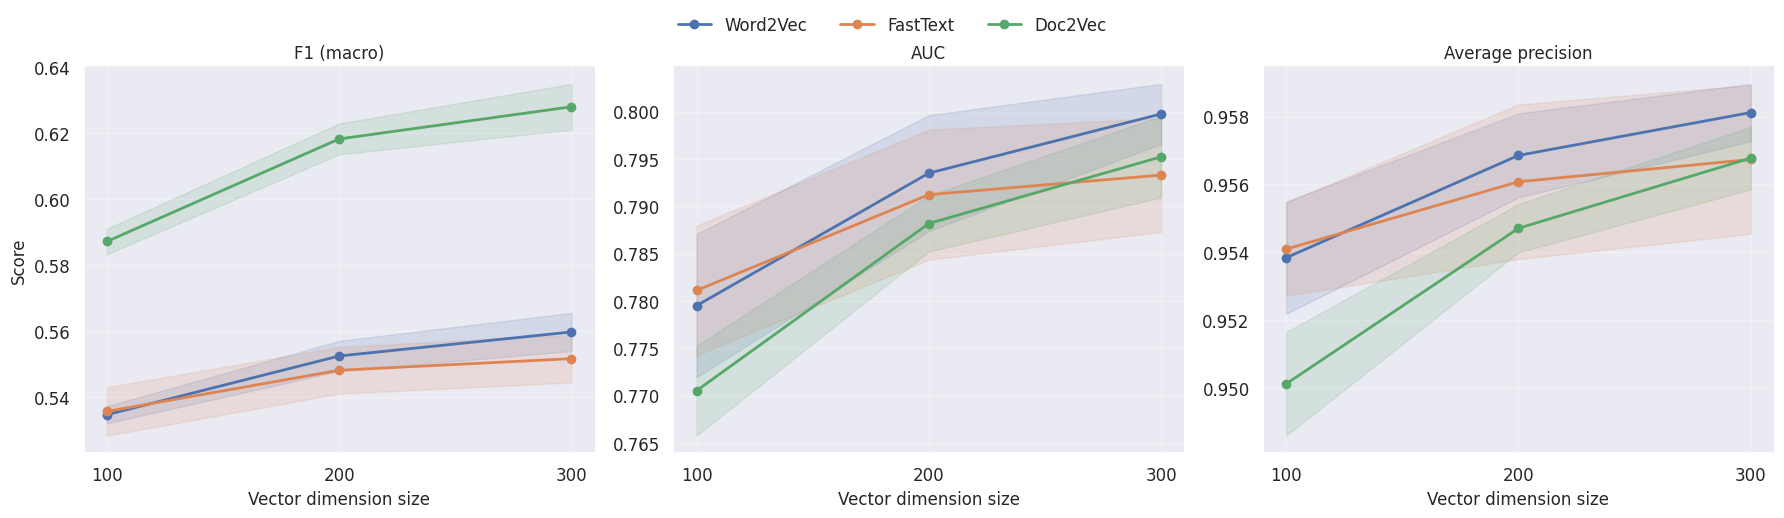

In [120]:
import matplotlib.pyplot as plt

METRICS = ["F1",        "AUC",  "AvgPrec"]
LABELS  = ["F1 (macro)","AUC",  "Average precision"]
MODELS  = ["Word2Vec", "FastText", "Doc2Vec"]
COLORS  = {"Word2Vec": sns.color_palette()[0], "FastText": sns.color_palette()[1], "Doc2Vec":sns.color_palette()[2]}
SIZES   = [100, 200, 300]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, label in zip(axes, METRICS, LABELS):
    for model in MODELS:
        subset = df_results[df_results["model"] == model].sort_values("size")
        ax.plot(subset["size"], subset[metric], marker="o",
                color=COLORS[model], linewidth=2, label=model)
        ax.fill_between(subset["size"],
                        subset[metric] - subset[f"{metric}_std"],
                        subset[metric] + subset[f"{metric}_std"],
                        color=COLORS[model], alpha=0.15)
    ax.set_title(label, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Vector dimension size", fontsize=12)
    ax.set_xticks(SIZES)
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=12)


axes[0].set_ylabel("Score", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.05), fontsize=12)

# # colored text labels on the right, outside the last subplot
# for i, model in enumerate(MODELS):
#     fig.text(1.01, 0.75 - i * 0.15, model,
#              color=COLORS[model],
#              fontsize=10, fontweight="500",
#              va="center", transform=axes[-1].transAxes)

plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.savefig("images/pretest/vectors_size_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Embedding sizes

cf python file

In [ ]:
# from sentence_transformers import SentenceTransformer

# # Load model (allow custom code)
# model = SentenceTransformer(
#     "jinaai/jina-embeddings-v5-text-nano",
#     trust_remote_code=True
# )

# # Encode with the task specified
# X_train_emb = model.encode(X_train, batch_size=8, show_progress_bar=True, task="classification")
# X_test_emb = model.encode(X_test, batch_size=8, show_progress_bar=True, task="classification")

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# from sklearn import preprocessing
# from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

# def eval_test_vect(model, kwargs, X_train, y_train, X_test, y_test, scale = True):
#     # pass the vectorized train and tes    
#     # scaling
#     if scale:
#         scaler = preprocessing.StandardScaler(with_mean=False).fit(X_train) # avoid dense matrix
#         X_train_scaled = scaler.transform(X_train)
#         X_test_scaled = scaler.transform(X_test)
#     else:
#         X_train_scaled, X_test_scaled = X_train, X_test

#     clf = model(**kwargs)
#     clf.fit(X_train_scaled, y_train)

#     y_pred_train = clf.predict(X_train_scaled)
#     ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

#     y_pred = clf.predict(X_test_scaled)
#     ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

#     f1_train, f1_test = f1_score(y_train, y_pred_train, average="macro"), f1_score(y_test, y_pred, average="macro")
#     ap_train, ap_test = average_precision_score(y_train, ypred_train_prob), average_precision_score(y_test, ypred_prob)
#     auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
#     prec_train, prec_test = precision_score(y_train, y_pred_train, average="macro"), precision_score(y_test, y_pred, average="macro")
#     rec_train, rec_test = recall_score(y_train, y_pred_train, average="macro"), recall_score(y_test, y_pred, average="macro")

#     final_train_metrics = {
#         "AUC": auc_train,
#         "F1": f1_train,
#         "Average Precision": ap_train,
#         "Recall": rec_train,
#         "Precision": prec_train,
#     }

#     test_metrics = {
#         "AUC": auc_test,
#         "F1": f1_test,
#         "Average Precision": ap_test,
#         "Recall": rec_test,
#         "Precision": prec_test,
#     }

#     # print summary
#     print("Final Train Results:")
#     for metric_name, metric_value in final_train_metrics.items():
#         print(f"{metric_name}: {metric_value}")

#     print("\nFinal Test Results:")
#     for metric_name, metric_value in test_metrics.items():
#         print(f"{metric_name}: {metric_value}")
#     return final_train_metrics, test_metrics

In [ ]:
# import time
# import pandas as pd
# import matplotlib.pyplot as plt
# import gc
# import json

# dims = [128, 256, 512, 768]
# rows = []

# # encode once at full size
# t0 = time.perf_counter()
# X_train_full = model.encode(
#     X_train, batch_size=32, show_progress_bar=True,
#     task="classification"
# )
# t1 = time.perf_counter()
# X_test_full = model.encode(
#     X_test, batch_size=32, show_progress_bar=True,
#     task="classification"
# )
# t2 = time.perf_counter()
# full_encode_s = t2 - t0

# for d in dims:
#     # slice instead of re-encoding
#     X_train_emb = X_train_full[:, :d]
#     X_test_emb  = X_test_full[:, :d]

#     t3 = time.perf_counter()
#     train_metrics, test_metrics = eval_test_vect(
#         LogisticRegression,
#         {"solver": "lbfgs", "max_iter": 1000},
#         X_train_emb, y_train,
#         X_test_emb,  y_test
#     )
#     t4 = time.perf_counter()

#     rows.append({
#         "dim":            d,
#         "encode_total_s": full_encode_s,  # same for all, encoding was done once
#         "eval_s":         t4 - t3,
#         "train_auc":      train_metrics["AUC"],
#         "train_f1":       train_metrics["F1"],
#         "train_ap":       train_metrics["Average Precision"],
#         "test_auc":       test_metrics["AUC"],
#         "test_f1":        test_metrics["F1"],
#         "test_ap":        test_metrics["Average Precision"],
#     })

# with open("embd_size.json", "w") as f:
#     json.dump(rows, f, indent=2)

# del X_train_full, X_test_full
# gc.collect()

# results_dims_df = pd.DataFrame(rows).sort_values("dim").reset_index(drop=True)
# display(results_dims_df)

cf python file embeddings_comp.py

In [32]:
import json

with open("res_files_saved/embed_size_cv.json") as json_file:
    json_data_emb = json.load(json_file)

In [33]:
json_data_emb[0].keys()

dict_keys(['dim', 'encode_total_s', 'eval_s', 'F1', 'F1_std', 'AUC', 'AUC_std', 'AvgPrec', 'AvgPrec_std', 'Precision', 'Precision_std', 'Recall', 'Recall_std', 'f1', 'auc', 'avg_prec', 'precision', 'recall'])

In [37]:
dims = [r['dim'] for r in json_data_emb][:-1]
dims # computed dim 1024 but corresponds to 512

[128, 256, 512, 768]

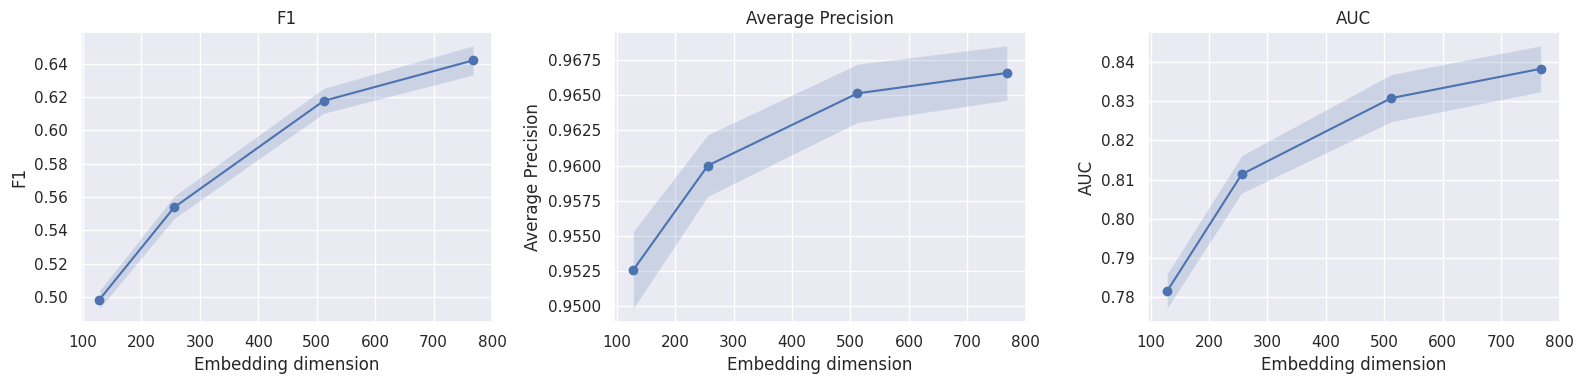

In [40]:
import seaborn as sns
dims = [r['dim'] for r in json_data_emb][:-1]

# Metrics for CV/train (with std)
metrics_cv = ['F1', 'AvgPrec', 'AUC', ] # 'Precision', 'Recall'

# Metrics for test
metrics_test = ['f1', 'avg_prec', 'auc',] # 'precision', 'recall'
sns.set_theme(style="darkgrid")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (m_cv, m_test) in enumerate(zip(metrics_cv, metrics_test)):
    cv_vals = [r[m_cv] for r in json_data_emb][:-1]
    cv_std = [r[m_cv + '_std'] for r in json_data_emb][:-1]
    test_vals = [r[m_test] for r in json_data_emb][:-1]

    ax = axes[i]
    
    # CV metric with error bars
    # ax.errorbar(dims, cv_vals, yerr=cv_std, label='CV/train', marker='o', capsize=3)
    ax.plot(dims, cv_vals, marker='o')
    
    # Test metric
    # ax.plot(dims, test_vals, label='Test', marker='s')

    ax.fill_between(
            dims,
            np.array(cv_vals) - np.array(cv_std),
            np.array(cv_vals) + np.array(cv_std),
            alpha=0.2,
        )
    
    ax.set_title(m_cv)
    if m_cv == "AvgPrec":
        ax.set_title("Average Precision")
    ax.set_xlabel('Embedding dimension')
    ax.set_ylabel(m_cv.replace("AvgPrec", "Average Precision"))
    ax.grid(True)
    # ax.legend()

plt.tight_layout()
plt.savefig("images/pretest/embed_size_metrics.pdf")
plt.show()


### 5. Test of different embeddings

In [ ]:
RESULTS = []  # accumulate across all cells

def run_cv(X, y, n_splits=5, scaling = True):
    """Scale + LR inside a pipeline, return mean CV metrics."""
    if scaling :
        pipe = Pipeline([
            # ("scaler", StandardScaler()),
            ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
        ])
    else:
        pipe = Pipeline([
            ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
        ])
    
    scores = cross_validate(pipe, X, y, cv=n_splits,
                            scoring=["f1_macro", "roc_auc",
                                     "average_precision",
                                     "precision_macro", "recall_macro"])
    return {
        "F1":            scores["test_f1_macro"].mean(),
        "F1_std":        scores["test_f1_macro"].std(),
        "AUC":           scores["test_roc_auc"].mean(),
        "AUC_std":       scores["test_roc_auc"].std(),
        "AvgPrec":       scores["test_average_precision"].mean(),
        "AvgPrec_std":   scores["test_average_precision"].std(),
        "Precision":     scores["test_precision_macro"].mean(),
        "Precision_std": scores["test_precision_macro"].std(),
        "Recall":        scores["test_recall_macro"].mean(),
        "Recall_std":    scores["test_recall_macro"].std(),
    }

def mean_embed_wv(texts, model): # sitck mean
    vecs = []
    for text in texts:
        words = text.split()
        ws = [model.wv[w] for w in words if w in model.wv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(model.vector_size))
    return np.array(vecs)

def log_result(name, metrics):
    RESULTS.append({"model": name, **metrics})
    print(f"{name:40s} : F1={metrics['F1']:.4f}  AUC={metrics['AUC']:.4f}")

all_texts = [stopwords_rmv(prep.process(t)) for t in X_train]
all_texts_tok = [t.split() for t in all_texts]

BEST_SIZE = 200 

#### Count + tfidf

In [11]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.model_selection import train_test_split, cross_validate

# no StandardScaler here — sparse matrices, TF-IDF already normalized
def run_cv_sparse(X, y, n_splits=5):
    clf = LogisticRegression(solver="lbfgs", max_iter=1000)
    scores = cross_validate(clf, X, y, cv=n_splits,
                            scoring=["f1_macro", "roc_auc",
                                     "average_precision",
                                     "precision_macro", "recall_macro"])
    return {
        "F1":            scores["test_f1_macro"].mean(),
        "F1_std":        scores["test_f1_macro"].std(),
        "AUC":           scores["test_roc_auc"].mean(),
        "AUC_std":       scores["test_roc_auc"].std(),
        "AvgPrec":       scores["test_average_precision"].mean(),
        "AvgPrec_std":   scores["test_average_precision"].std(),
        "Precision":     scores["test_precision_macro"].mean(),
        "Precision_std": scores["test_precision_macro"].std(),
        "Recall":        scores["test_recall_macro"].mean(),
        "Recall_std":    scores["test_recall_macro"].std(),
    }

cv_vec   = CountVectorizer()
tfidf_vec = TfidfVectorizer()

X_cv    = cv_vec.fit_transform(all_texts)
X_tfidf = tfidf_vec.fit_transform(all_texts)

log_result("CountVectorizer",  run_cv_sparse(X_cv,    y_train))
log_result("TF-IDF",           run_cv_sparse(X_tfidf, y_train))

CountVectorizer                          : F1=0.7108  AUC=0.8551
TF-IDF                                   : F1=0.6258  AUC=0.8574


#### Word2V, Fastext, D2V

In [13]:
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.pipeline import Pipeline

# Word2Vec
w2v = Word2Vec(sentences=all_texts_tok, vector_size=BEST_SIZE,
               window=5, min_count=5, sg=1, epochs=5, workers=3)
log_result(f"Word2Vec (trained {BEST_SIZE}d)", run_cv(mean_embed_wv(all_texts, w2v), y_train))

# FastText
ft = FastText(sentences=all_texts_tok, vector_size=BEST_SIZE,
              window=5, min_count=1, sg=1, epochs=5, workers=3)
log_result(f"FastText (trained {BEST_SIZE}d)", run_cv(mean_embed_wv(all_texts, ft), y_train))

# Doc2Vec
tagged = [TaggedDocument(t.split(), [i]) for i, t in enumerate(all_texts)]
d2v = Doc2Vec(tagged, vector_size=BEST_SIZE, window=5,
              min_count=1, dm=0, epochs=20, workers=4)

X_d2v = np.array([d2v.infer_vector(t.split()) for t in all_texts])
log_result(f"Doc2Vec (trained {BEST_SIZE}d)", run_cv(X_d2v, y_train))

Word2Vec (trained 200d)                  : F1=0.5316  AUC=0.7842
FastText (trained 200d)                  : F1=0.5313  AUC=0.7787
Doc2Vec (trained 200d)                   : F1=0.5974  AUC=0.7826


In [ ]:
# from sentence_transformers import SentenceTransformer

# model = SentenceTransformer(
#     "intfloat/multilingual-e5-base", 
# )
# model.save("./model_emb")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4303.94it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.75s/it]


#### W2V, Fastext pretrained (ppti)

In [ ]:
from gensim.models import KeyedVectors
from gensim.models.fasttext import load_facebook_model

# cc.fr.300.vec — behaves like Word2Vec, no subword info
kv_vec = KeyedVectors.load_word2vec_format("cc.fr.300.vec", binary=False)
log_result("cc.fr.300.vec (W2V-like)", run_cv(mean_embed_wv(all_texts, type('M', (), {'wv': kv_vec, 'vector_size': 300})()), y_train))

# cleaner helper that works directly with KeyedVectors
def mean_embed_kv(texts, kv):
    vecs = []
    for text in texts:
        words = text.split()
        ws = [kv[w] for w in words if w in kv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(kv.vector_size))
    return np.array(vecs)

log_result("cc.fr.300.vec (W2V-like)", run_cv(mean_embed_kv(all_texts, kv_vec), y_train))

ft_bin = load_facebook_model("cc.fr.300.bin")
log_result("cc.fr.300.bin (FastText)",  run_cv(mean_embed_wv(all_texts, ft_bin), y_train))

In [58]:
with open("w2v_ft_results.json") as json_file:
    json_data_w2v_ft = json.load(json_file)

In [59]:
log_result("Word2Vec", json_data_w2v_ft[0])
log_result("FastText", json_data_w2v_ft[1])

Word2Vec                                 : F1=0.5588  AUC=0.7919
FastText                                 : F1=0.5688  AUC=0.7982


In [ ]:
# tmp sav
RESULTS

[{'model': 'CountVectorizer',
  'F1': np.float64(0.7107755401548113),
  'F1_std': np.float64(0.0023119873468460217),
  'AUC': np.float64(0.8551356586808134),
  'AUC_std': np.float64(0.005133350290685036),
  'AvgPrec': np.float64(0.9704856842962715),
  'AvgPrec_std': np.float64(0.0016004048988171055),
  'Precision': np.float64(0.8054680312654723),
  'Precision_std': np.float64(0.005292903690409735),
  'Recall': np.float64(0.6703569677447078),
  'Recall_std': np.float64(0.002387635175341692)},
 {'model': 'TF-IDF',
  'F1': np.float64(0.6258414647617534),
  'F1_std': np.float64(0.005271053345967234),
  'AUC': np.float64(0.8573911765661943),
  'AUC_std': np.float64(0.002944437844377875),
  'AvgPrec': np.float64(0.9717770274068764),
  'AvgPrec_std': np.float64(0.0008801304888786758),
  'Precision': np.float64(0.8450478165609656),
  'Precision_std': np.float64(0.00925318403843749),
  'Recall': np.float64(0.5935133144802976),
  'Recall_std': np.float64(0.003754421874749323)},
 {'model': 'Word2

#### Transformers

In [53]:
from sentence_transformers import SentenceTransformer

# texts WITHOUT stopword removal for transformers
raw_texts = [prep.process(t) for t in X_train]  # light prep, keep stopwords

st_model = SentenceTransformer("./model_emb", device = "cpu")

X_st = st_model.encode(raw_texts, batch_size=8, show_progress_bar=True)
log_result(f"Transformer ({model_name.split('/')[-1]})", run_cv(X_st, y_train))

Batches: 100%|██████████| 5742/5742 [41:00<00:00,  2.33it/s] 


NameError: name 'model_name' is not defined

In [54]:
log_result(f"Transformer (embed)", run_cv(X_st, y_train))

Transformer (embed)                      : F1=0.6382  AUC=0.8360


In [60]:
RESULTS 

[{'model': 'CountVectorizer',
  'F1': np.float64(0.7107755401548113),
  'F1_std': np.float64(0.0023119873468460217),
  'AUC': np.float64(0.8551356586808134),
  'AUC_std': np.float64(0.005133350290685036),
  'AvgPrec': np.float64(0.9704856842962715),
  'AvgPrec_std': np.float64(0.0016004048988171055),
  'Precision': np.float64(0.8054680312654723),
  'Precision_std': np.float64(0.005292903690409735),
  'Recall': np.float64(0.6703569677447078),
  'Recall_std': np.float64(0.002387635175341692)},
 {'model': 'TF-IDF',
  'F1': np.float64(0.6258414647617534),
  'F1_std': np.float64(0.005271053345967234),
  'AUC': np.float64(0.8573911765661943),
  'AUC_std': np.float64(0.002944437844377875),
  'AvgPrec': np.float64(0.9717770274068764),
  'AvgPrec_std': np.float64(0.0008801304888786758),
  'Precision': np.float64(0.8450478165609656),
  'Precision_std': np.float64(0.00925318403843749),
  'Recall': np.float64(0.5935133144802976),
  'Recall_std': np.float64(0.003754421874749323)},
 {'model': 'Word2

                   model       F1   F1_std      AUC  AUC_std  AvgPrec  AvgPrec_std  Precision  Precision_std   Recall  Recall_std
         CountVectorizer 0.710776 0.002312 0.855136 0.005133 0.970486     0.001600   0.805468       0.005293 0.670357    0.002388
                  TF-IDF 0.625841 0.005271 0.857391 0.002944 0.971777     0.000880   0.845048       0.009253 0.593513    0.003754
 Word2Vec (trained 200d) 0.531644 0.004075 0.784213 0.007982 0.955020     0.001636   0.676570       0.017615 0.532735    0.002450
 FastText (trained 200d) 0.531326 0.008064 0.778702 0.007059 0.953680     0.001567   0.678098       0.023325 0.532603    0.004898
  Doc2Vec (trained 200d) 0.597400 0.004603 0.782554 0.003371 0.952957     0.000916   0.781072       0.007129 0.574742    0.003205
     Transformer (embed) 0.638209 0.009542 0.835986 0.006431 0.966087     0.001887   0.820268       0.005835 0.603599    0.007213
cc.fr.300.vec (W2V-like) 0.558755 0.004718 0.791933 0.004566 0.955847     0.001592   0.686

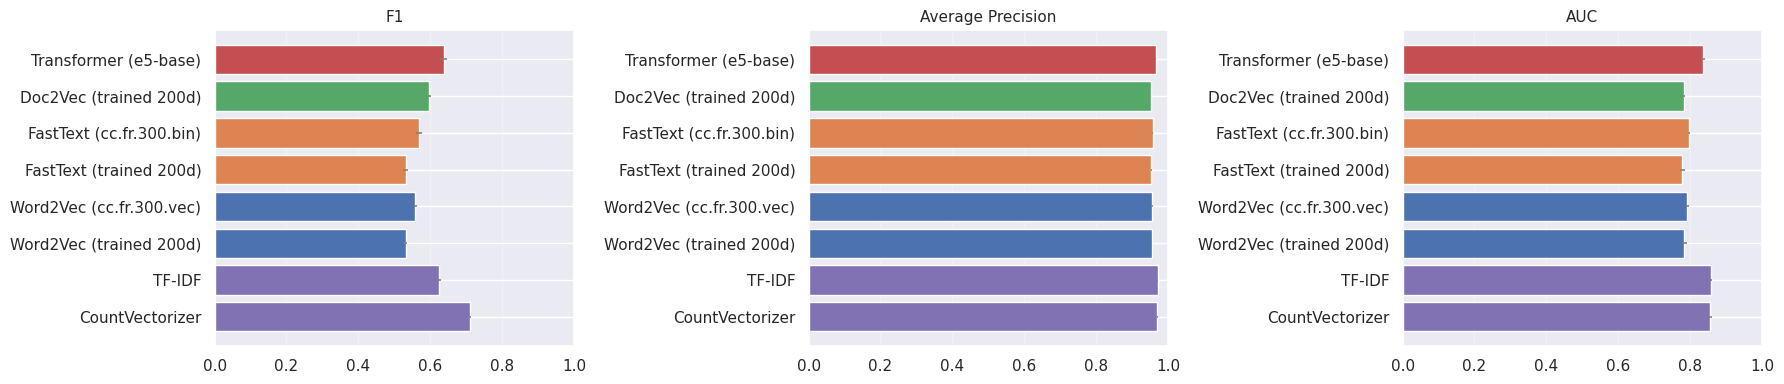

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.DataFrame(RESULTS)
print(df_results.to_string(index=False))


order = [
    "CountVectorizer",
    "TF-IDF",
    "Word2Vec (trained 200d)",
    "cc.fr.300.vec (W2V-like)",
    "FastText (trained 200d)",
    "cc.fr.300.bin (FastText)",
    "Doc2Vec (trained 200d)",
    "Transformer (embed)",
]

df_plot = df_results.set_index("model").reindex([m for m in order if m in df_results["model"].values]).reset_index()
df_plot = df_plot.replace({
    "cc.fr.300.vec (W2V-like)": "Word2Vec (cc.fr.300.vec)",
    "cc.fr.300.bin (FastText)": "FastText (cc.fr.300.bin)",
    "Transformer (embed)": "Transformer (e5-base)",})

# same plotting code as before, adapted for model names on x axis

METRICS = ["F1", "AvgPrec" , "AUC", ] #  "Precision", "Recall"
LABELS  = ["F1", "Average Precision", "AUC", ]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, metric, label in zip(axes, METRICS, LABELS):
    vals = df_plot[metric]
    colors = [sns.color_palette()[0] if "Word2Vec" in m 
              else sns.color_palette()[1] if "Fast" in m
              else sns.color_palette()[2] if "Doc" in m
              else sns.color_palette()[3] if "Transformer" in m
              else sns.color_palette()[4]
              for m in df_plot["model"]]
    ax.barh(df_plot["model"], vals, color=colors, xerr=df_plot[f"{metric}_std"], error_kw={"elinewidth": 1.2, "ecolor": "gray"})
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, 1)
    # ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("images/pretest/vectorizer_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()

### 5. Test of different embeddings (old)

In [ ]:
# test with tfidf, countvect, embeddings trained, pretrained and hugging face   

CountVectoriser

In [10]:
from sklearn import preprocessing
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, precision_score, recall_score

def eval_test_vect(model, kwargs, X_train, y_train, X_test, y_test):
    # pass the vectorized train and tes    
    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(X_train) # avoid dense matrix
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train, average="macro"), f1_score(y_test, y_pred, average="macro")
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train, average="macro"), precision_score(y_test, y_pred, average="macro")
    rec_train, rec_test = recall_score(y_train, y_pred_train, average="macro"), recall_score(y_test, y_pred, average="macro")

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [97]:
vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=max_feat, preprocessor=prep)

vectorised_train = vectoriser.fit_transform(X_train)
vectorised_test = vectoriser.transform(X_test)

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, vectorised_train, y_train, vectorised_test, y_test)

Final Train Results:
AUC: 0.8038526191652877
F1: 0.6281318470484801
Average Precision: 0.8915821019408632
Recall: 0.5967295173009735
Precision: 0.7967607085117413

Final Test Results:
AUC: 0.7866299213751982
F1: 0.6126777613312339
Average Precision: 0.8889692430252729
Recall: 0.5859391658326059
Precision: 0.7721412535959307


TdfidfVectorizer

In [98]:
vectoriser = build_vectorizer(name="tfidf", stop_words=final_stopwords_list, max_features=max_feat, preprocessor=prep)

vectorised_train = vectoriser.fit_transform(X_train)
vectorised_test = vectoriser.transform(X_test)

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, vectorised_train, y_train, vectorised_test, y_test)

Final Train Results:
AUC: 0.7998604032560566
F1: 0.607326377120612
Average Precision: 0.8880230319262826
Recall: 0.5818324116645853
Precision: 0.7777865542866504

Final Test Results:
AUC: 0.7832947101563639
F1: 0.5981539834067274
Average Precision: 0.8865115126443729
Recall: 0.5756085980519269
Precision: 0.7617969403537768


Embedding trained on our data

In [6]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = True,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [76]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

# preprocess train before word2vec
prep_X_train = [prep.process(txt) for txt in X_train]

# text = [t.split() for t in prep_X_train] 

# the following configuration is the default configuration
# w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                # vector_size=100, window=5,               ### here we train a cbow model
                                # min_count=5,
                                # sample=0.001, workers=3,
                                # sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                # cbow_mean=1, epochs=5)

# w2v.save("W2v-pres-exp5.dat")
# pour load
w2v = gensim.models.Word2Vec.load("W2v-pres-exp5.dat")

def embed(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
    
    if len(vec) == 0:
        return np.zeros(w2v.vector_size)
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0) # keep sum

2026-03-16 21:16:57,166 : INFO : loading Word2Vec object from W2v-pres-exp5.dat
2026-03-16 21:16:57,196 : INFO : loading wv recursively from W2v-pres-exp5.dat.wv.* with mmap=None
2026-03-16 21:16:57,198 : INFO : setting ignored attribute cum_table to None
2026-03-16 21:16:57,325 : INFO : Word2Vec lifecycle event {'fname': 'W2v-pres-exp5.dat', 'datetime': '2026-03-16T21:16:57.324747', 'gensim': '4.4.0', 'python': '3.12.10 (main, Apr 22 2025, 00:00:00) [GCC 14.2.1 20240912 (Red Hat 14.2.1-3)]', 'platform': 'Linux-6.14.5-100.fc40.x86_64-x86_64-with-glibc2.39', 'event': 'loaded'}


In [91]:
def stopwords_rmv(text, stopwords=final_stopwords_list):
    return " ".join([word for word in text.split() if word not in stopwords])

stopwords_rmv(prep.process(X_train[0]))

'partenaires sociaux'

In [94]:
# removing stop words
prep_X_train = [(stopwords_rmv(prep.process(txt))) for txt in X_train]
prep_X_test = [(stopwords_rmv(prep.process(txt))) for txt in X_test]

prep_X_train_vect = [embed(text, w2v, mean=True) for text in prep_X_train]
prep_X_test_vect = [embed(text, w2v, mean=True) for text in prep_X_test]

In [95]:
eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, prep_X_train_vect, y_train, prep_X_test_vect, y_test)

Final Train Results:
AUC: 0.5996820164548115
F1: 0.4673220963276444
Average Precision: 0.8691756372303208
Recall: 0.5008829619579825
Precision: 0.6050424371862283

Final Test Results:
AUC: 0.5954270824385075
F1: 0.4715488510121158
Average Precision: 0.8696140369490885
Recall: 0.5029714874384776
Precision: 0.7289249032946512


Using pretrained

In [ ]:
# frWac, wiki.fr.vec, cc.fr.300.vec

In [37]:
from gensim.models import KeyedVectors

# Path to your local file
file_path = "cc.fr.300.vec" # similar to what have with word2vec?
w = KeyedVectors.load_word2vec_format(file_path, binary=False)

2026-03-16 15:30:00,675 : INFO : loading projection weights from cc.fr.300.vec
2026-03-16 15:58:22,136 : INFO : KeyedVectors lifecycle event {'msg': 'loaded (2000000, 300) matrix of type float32 from cc.fr.300.vec', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-03-16T15:58:22.136592', 'gensim': '4.4.0', 'python': '3.12.10 (main, Apr 22 2025, 00:00:00) [GCC 14.2.1 20240912 (Red Hat 14.2.1-3)]', 'platform': 'Linux-6.14.5-100.fc40.x86_64-x86_64-with-glibc2.39', 'event': 'load_word2vec_format'}


In [103]:
def embed(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.key_to_index[word] 
            vec.append(w2v[idx])
    
    if len(vec) == 0:
        return np.zeros(w2v.vector_size)
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0) # keep sum

prep_X_train = [(stopwords_rmv(prep.process(txt))) for txt in X_train]
prep_X_test = [(stopwords_rmv(prep.process(txt))) for txt in X_test]

prep_X_train_vect = [embed(text, w, mean=True) for text in prep_X_train]
prep_X_test_vect = [embed(text, w, mean=True) for text in prep_X_test]

In [104]:
lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 2000},
    prep_X_train_vect,
    y_train,    
    prep_X_test_vect,
    y_test
)

Final Train Results:
AUC: 0.6502732606949646
F1: 0.47047608598671936
Average Precision: 0.8694133706375398
Recall: 0.5019261842654038
Precision: 0.583467484194614

Final Test Results:
AUC: 0.6542657301212168
F1: 0.4751035744558221
Average Precision: 0.8698973965435007
Recall: 0.5042131892822016
Precision: 0.6454760755098756


Using sentence transformers

In [105]:
model

SentenceTransformer(
  (transformer): Transformer(
    (model): JinaEmbeddingsV5Model(
      (base_model): MixedModel(
        (model): EuroBertModel(
          (embed_tokens): Embedding(128256, 768, padding_idx=128001)
          (layers): ModuleList(
            (0-11): 12 x EuroBertDecoderLayer(
              (self_attn): EuroBertAttention(
                (q_proj): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=False)
                  (lora_dropout): ModuleDict(
                    (retrieval): Dropout(p=0.1, inplace=False)
                    (text-matching): Dropout(p=0.1, inplace=False)
                    (clustering): Dropout(p=0.1, inplace=False)
                    (classification): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (retrieval): Linear(in_features=768, out_features=32, bias=False)
                    (text-matching): Linear(in_features=768, out_features=3

In [30]:
from sentence_transformers import SentenceTransformer

# Load model (allow custom code)
model = SentenceTransformer(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True
)

# Encode with the task specified
X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True, task="classification")
X_test_emb = model.encode(X_test, batch_size=32, show_progress_bar=True, task="classification")

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-16 14:56:23,723 : INFO : Use pytorch device_name: cuda:0
2026-03-16 14:56:23,724 : INFO : Load pretrained SentenceTransformer: jinaai/jina-embeddings-v5-text-nano
2026-03-16 14:56:23,886 : INFO : HTTP Request: HEAD https://huggingface.co/jinaai/jina-embeddings-v5-text-nano/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-16 14:56:23,900 : INFO : HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jinaai/jina-embeddings-v5-text-nano/062e9a85a87b4dd57458a651a65c642a6809f80e/modules.json "HTTP/1.1 200 OK"
2026-03-16 14:56:23,915 : INFO : HTTP Request: GET https://huggingface.co/api/resolve-cache/models/jinaai/jina-embeddings-v5-text-nano/062e9

In [31]:
lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    X_train_emb,
    y_train,    
    X_test_emb,
    y_test
) # 768 dimensions

Final Train Results:
AUC: 0.8659724208146591
F1: 0.7070033325602895
Average Precision: 0.9084828924810417
Recall: 0.6657911987629015
Precision: 0.8085273362999479

Final Test Results:
AUC: 0.8475847529015662
F1: 0.6816081616665826
Average Precision: 0.9035831418743665
Recall: 0.6461205682401616
Precision: 0.7712443875927635


Testing different embedding size

In [ ]:
X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True, task="retrieval", truncate_dim=128)
X_test_emb = model.encode(X_test, batch_size=32, show_progress_bar=True, task="retrieval", truncate_dim=128)

lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    X_train_emb,
    y_train,    
    X_test_emb,
    y_test
)

In [106]:
# Encode with the task specified

for d in [100, 300, 512]:
    X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True, task="retrieval", truncate_dim=d)
    X_test_emb = model.encode(X_test, batch_size=32, show_progress_bar=True, task="retrieval", truncate_dim=d)

    lr = build_model(name="logreg")

    eval_test_vect(LogisticRegression,
        {"solver": "lbfgs", "max_iter": 1000},
        X_train_emb,
        y_train,    
        X_test_emb,
        y_test
    )

Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:35<00:00,  3.76it/s]


Final Train Results:
AUC: 0.7478334023119391
F1: 0.5257819748257333
Average Precision: 0.8758776698903379
Recall: 0.5300740892176148
Precision: 0.7287952186397438

Final Test Results:
AUC: 0.756098433164257
F1: 0.5202652599891178
Average Precision: 0.8750427603148588
Recall: 0.5266190935673098
Precision: 0.6902379640231825


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.80it/s]


Final Train Results:
AUC: 0.8103200920389764
F1: 0.6189486946746068
Average Precision: 0.8901531781547718
Recall: 0.5907568060500799
Precision: 0.770112821084718

Final Test Results:
AUC: 0.8071283068598092
F1: 0.605205166563292
Average Precision: 0.887813092409442
Recall: 0.5810820349619662
Precision: 0.7495019591723322


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:36<00:00,  3.70it/s]


Final Train Results:
AUC: 0.8432925816657064
F1: 0.6699974816209231
Average Precision: 0.90013821488323
Recall: 0.6320233651620804
Precision: 0.7923937615613721

Final Test Results:
AUC: 0.8315039931703567
F1: 0.6529743027957757
Average Precision: 0.8971472529901653
Recall: 0.6198672294995835
Precision: 0.7605382157685838


In [15]:
def eval_test_vect(model, kwargs, X_train, y_train, X_test, y_test):
    # pass the vectorized train and tes    
    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(X_train) # avoid dense matrix
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train, average="macro"), f1_score(y_test, y_pred, average="macro")
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train, average="macro"), precision_score(y_test, y_pred, average="macro")
    rec_train, rec_test = recall_score(y_train, y_pred_train, average="macro"), recall_score(y_test, y_pred, average="macro")

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")
    return final_train_metrics, test_metrics

In [8]:
from sentence_transformers import SentenceTransformer

# Load model (allow custom code)
model = SentenceTransformer(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True
)

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-nano:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-nano:
- configuration_eurobert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-na

In [28]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import gc

# Dimensions to test
dims = [128, 256, 512, 768]

rows = []

for d in dims:
    # --- timing: encoding ---
    t0 = time.perf_counter()
    X_train_emb = model.encode(
        X_train, batch_size=32, show_progress_bar=True,
        task="classification", truncate_dim=d
    )
    t1 = time.perf_counter()

    X_test_emb = model.encode(
        X_test, batch_size=32, show_progress_bar=True,
        task="classification", truncate_dim=d
    )
    t2 = time.perf_counter()

    train_encode_s = t1 - t0
    test_encode_s = t2 - t1
    total_encode_s = t2 - t0

    # --- timing: model fit/eval ---
    t3 = time.perf_counter()
    train_metrics, test_metrics = eval_test_vect(
        LogisticRegression,
        {"solver": "lbfgs", "max_iter": 1000},
        X_train_emb, y_train,
        X_test_emb, y_test
    )
    t4 = time.perf_counter()
    eval_s = t4 - t3

    rows.append({
        "dim": d,
        "encode_train_s": train_encode_s,
        "encode_test_s": test_encode_s,
        "encode_total_s": total_encode_s,
        "eval_s": eval_s,
        "train_auc": train_metrics["AUC"],
        "train_f1": train_metrics["F1"],
        "train_ap": train_metrics["Average Precision"],
        "train_recall": train_metrics["Recall"],
        "train_precision": train_metrics["Precision"],
        "test_auc": test_metrics["AUC"],
        "test_f1": test_metrics["F1"],
        "test_ap": test_metrics["Average Precision"],
        "test_recall": test_metrics["Recall"],
        "test_precision": test_metrics["Precision"],
    })

    del X_train_emb, X_test_emb
    gc.collect()

results_dims_df = pd.DataFrame(rows).sort_values("dim").reset_index(drop=True)
display(results_dims_df)

# Optional save
# results_dims_df.to_csv("images/pretest/embedding_dim_results.csv", index=False)

Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.82it/s]


Final Train Results:
AUC: 0.7469553447961055
F1: 0.5299448650281362
Average Precision: 0.8764434248595432
Recall: 0.5325178003771808
Precision: 0.7436073782638214

Final Test Results:
AUC: 0.7502447577361225
F1: 0.5281573937206773
Average Precision: 0.8761777313466493
Recall: 0.531526334680483
Precision: 0.7433458991350259


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.79it/s]


Final Train Results:
AUC: 0.7818082883040596
F1: 0.577731347672982
Average Precision: 0.883241796868969
Recall: 0.5616297404639159
Precision: 0.7564794004453663

Final Test Results:
AUC: 0.7756165890540585
F1: 0.5712907241442302
Average Precision: 0.8822303419941642
Recall: 0.5574734848560521
Precision: 0.7430869715840438


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:35<00:00,  3.77it/s]


Final Train Results:
AUC: 0.8158801556844799
F1: 0.6329423866384529
Average Precision: 0.8927207740772959
Recall: 0.6014595270112693
Precision: 0.776576767284886

Final Test Results:
AUC: 0.8009483987696521
F1: 0.6135170087527075
Average Precision: 0.8893412136827343
Recall: 0.5874890206960296
Precision: 0.7477732126200523


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.80it/s]


Final Train Results:
AUC: 0.8374483143407354
F1: 0.6666926635427917
Average Precision: 0.899406730100278
Recall: 0.6290336372122358
Precision: 0.7922910605531671

Final Test Results:
AUC: 0.8126023430950085
F1: 0.647775033150693
Average Precision: 0.896033595250269
Recall: 0.6152847227355331
Precision: 0.7594142322110848


,dim,encode_train_s,encode_test_s,encode_total_s,eval_s,train_auc,train_f1,train_ap,train_recall,train_precision,test_auc,test_f1,test_ap,test_recall,test_precision
0,128,378.276180,94.488076,472.764256,8.165563,0.746955,0.529945,0.876443,0.532518,0.743607,0.750245,0.528157,0.876178,0.531526,0.743346
1,256,379.404075,95.269840,474.673915,7.939215,0.781808,0.577731,0.883242,0.561630,0.756479,0.775617,0.571291,0.882230,0.557473,0.743087
2,512,379.766368,95.562542,475.328910,24.975003,0.815880,0.632942,0.892721,0.601460,0.776577,0.800948,0.613517,0.889341,0.587489,0.747773
3,768,379.238191,94.828851,474.067041,31.477183,0.837448,0.666693,0.899407,0.629034,0.792291,0.812602,0.647775,0.896034,0.615285,0.759414


In [30]:
30/4

7.5

In [32]:
(470)/60

7.833333333333333

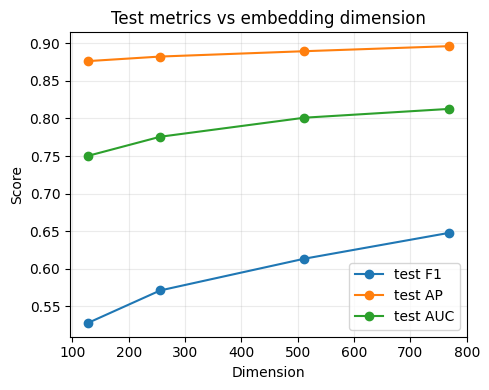

In [39]:
# --- plots ---
# fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = plt.subplots(1, 1, figsize=(5, 4))

# Encoding times
# axes[0].plot(results_dims_df["dim"], results_dims_df["encode_train_s"], marker="o", label="encode train")
# axes[0].plot(results_dims_df["dim"], results_dims_df["encode_test_s"], marker="o", label="encode test")
# axes[0].plot(results_dims_df["dim"], results_dims_df["encode_total_s"], marker="o", label="encode total")
# axes[0].set_title("Encoding time vs embedding dimension")
# axes[0].set_xlabel("Dimension")
# axes[0].set_ylabel("Time (s)")
# axes[0].grid(alpha=0.25)
# axes[0].legend()

# Test metrics
# axes[1].plot(results_dims_df["dim"], results_dims_df["test_f1"], marker="o", label="test F1")
# axes[1].plot(results_dims_df["dim"], results_dims_df["test_ap"], marker="o", label="test AP")
# axes[1].plot(results_dims_df["dim"], results_dims_df["test_auc"], marker="o", label="test AUC")
# axes[1].set_title("Test metrics vs embedding dimension")
# axes[1].set_xlabel("Dimension")
# axes[1].set_ylabel("Score")
# axes[1].grid(alpha=0.25)
# axes[1].legend()

plt.plot(results_dims_df["dim"], results_dims_df["test_f1"], marker="o", label="test F1")
plt.plot(results_dims_df["dim"], results_dims_df["test_ap"], marker="o", label="test AP")
plt.plot(results_dims_df["dim"], results_dims_df["test_auc"], marker="o", label="test AUC")
plt.title("Test metrics vs embedding dimension")
plt.xlabel("Dimension")
plt.ylabel("Score")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.savefig("images/pretest/embeddings_size_score.pdf")
plt.show()

### 6. POS Tag RNN

In [50]:
# POS tag 

In [69]:
prep = Preprocessing(low_case = False,
                rm_punctuation = False,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = True, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

def get_pos_text(X):
    final_pos = []
    for text in X:
        _, pos_tag = prep.process(text)
        tags_l = []
        for tags in pos_tag:
            tags_l.append(tags[1])
        final_pos.append(tags_l)
    return final_pos

In [72]:
pos_train = get_pos_text(X_train)

In [ ]:
from nltk.tag.crf import CRFTagger
tagger = CRFTagger()

## Re baseline

In [ ]:
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, precision_score, recall_score    

f1_train, f1_test = f1_score(y_train, np.ones(len(y_train)), average='macro'), f1_score(y_test, np.ones(len(y_test)), average='macro')
ap_train, ap_test = average_precision_score(y_train, np.ones(len(y_train))), average_precision_score(y_test, np.ones(len(y_test)))
auc_train, auc_test = roc_auc_score(y_train, np.ones(len(y_train))), roc_auc_score(y_test, np.ones(len(y_test)))
prec_train, prec_test = precision_score(y_train, np.ones(len(y_train))), precision_score(y_test, np.ones(len(y_test)), average='macro')
rec_train, rec_test = recall_score(y_train, np.ones(len(y_train))), recall_score(y_test, np.ones(len(y_test)), average='macro')

print(auc_train, auc_test)
print(f1_train, f1_test)
print(ap_train, ap_test)
print(rec_train, rec_test)
print(prec_train, prec_test)

0.5 0.5
0.4649472286293423 0.46493639625366945
0.8689745264532985 0.8689366890185491
1.0 0.5
0.8689745264532985 0.4344683445092746


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [58]:
np.random.seed(0)
n_runs = 30

f1_train_scores, f1_test_scores = [], []
ap_train_scores, ap_test_scores = [], []
auc_train_scores, auc_test_scores = [], []
prec_train_scores, prec_test_scores = [], []
rec_train_scores, rec_test_scores = [], []

for _ in range(n_runs):
    a = np.random.choice([-1, 1], size=len(y_train))
    b = np.random.choice([-1, 1], size=len(y_test))

    f1_train_scores.append(f1_score(y_train, a, average="macro"))
    f1_test_scores.append(f1_score(y_test, b, average="macro"))

    ap_train_scores.append(average_precision_score(y_train, a))
    ap_test_scores.append(average_precision_score(y_test, b))

    auc_train_scores.append(roc_auc_score(y_train, np.where(a == 1, 1, 0)))
    auc_test_scores.append(roc_auc_score(y_test, np.where(b == 1, 1, 0)))

    prec_train_scores.append(precision_score(y_train, a, average='macro'))
    prec_test_scores.append(precision_score(y_test, b, average='macro'))

    rec_train_scores.append(recall_score(y_train, a, average='macro'))
    rec_test_scores.append(recall_score(y_test, b, average='macro'))

print("Mean over 30 random runs:")
print("AUC:", np.mean(auc_train_scores), np.mean(auc_test_scores))
print("F1:", np.mean(f1_train_scores), np.mean(f1_test_scores))
print("AP:", np.mean(ap_train_scores), np.mean(ap_test_scores))
print("Recall:", np.mean(rec_train_scores), np.mean(rec_test_scores))
print("Precision:", np.mean(prec_train_scores), np.mean(prec_test_scores))

Mean over 30 random runs:
AUC: 0.5008081654681841 0.4998535216013436
F1: 0.4214766679305052 0.42074730693105805
AP: 0.8691598115777023 0.8689088772530399
Recall: 0.5008081654681842 0.49985352160134355
Precision: 0.5003680675841884 0.49993328426316347
